<a href="https://colab.research.google.com/github/sungfeliks/Lightweight-Mixture-of-Experts-with-Knowledge-Distillation-Vision-Language-Model/blob/main/02_teacher_mammoclip_cbisd_ddsm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Runtime & Environment**

## **GPU Check**

In [1]:
import os
import platform
import subprocess
import sys

print("Python :", sys.version)
print("Platform:", platform.platform())

try:
    subprocess.run(["nvidia-smi"], check=True)
except Exception as exc:
    raise RuntimeError(
        "GPU is off. Please Change Runtime Type!"
    ) from exc

Python : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35


## **Mount Google Drive**

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## **Add CBIS-DDSM**

In [3]:
from pathlib import Path
import shutil

DRIVE_DATASET_ZIP = Path(
    "/content/drive/MyDrive/Research/datasets/cbis_ddsm_awsaf.zip"
)

LOCAL_DATA_PARENT = Path("/content")
CBIS_ROOT = LOCAL_DATA_PARENT / "cbis_ddsm_awsaf"

if not CBIS_ROOT.exists():
    if not DRIVE_DATASET_ZIP.exists():
        raise FileNotFoundError(
            f"No dataset archive found: {DRIVE_DATASET_ZIP}"
        )

    print("Extracting the dataset to Colab’s local storage...")

    shutil.unpack_archive(
        filename=str(DRIVE_DATASET_ZIP),
        extract_dir=str(CBIS_ROOT),
    )

    print("Extraction complete.")
else:
    print("The dataset is now available:", CBIS_ROOT)

print("CBIS root exists:", CBIS_ROOT.exists())
print("JPEG folder exists:", (CBIS_ROOT / "jpeg").exists())

Extracting the dataset to Colab’s local storage...
Extraction complete.
CBIS root exists: True
JPEG folder exists: True


## **Clone Mammo-CLIP Repository**

In [4]:
REPO_ROOT = Path("/content/Mammo-CLIP")

if not REPO_ROOT.exists():
    !git clone https://github.com/batmanlab/Mammo-CLIP.git /content/Mammo-CLIP
else:
    print("The repository is now available:", REPO_ROOT)

Cloning into '/content/Mammo-CLIP'...
remote: Enumerating objects: 987, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 987 (delta 66), reused 52 (delta 50), pack-reused 899 (from 2)
Receiving objects: 100% (987/987), 3.10 MiB | 6.37 MiB/s, done.
Resolving deltas: 100% (580/580), done.


## **Path Configuration**

In [5]:
PROJECT_ROOT = Path("/content/drive/MyDrive/Research")

CSV_DIR = PROJECT_ROOT / "processed"
# CBIS_ROOT = PROJECT_ROOT / "cbis_ddsm_awsaf"

TRAIN_CSV = CSV_DIR / "cbis_train.csv"
VAL_CSV = CSV_DIR / "cbis_val.csv"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "teacher_mammoclip_b2"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Train CSV    :", TRAIN_CSV)
print("Validation   :", VAL_CSV)
print("CBIS root    :", CBIS_ROOT)
print("Output       :", OUTPUT_DIR)

Project root : /content/drive/MyDrive/Research
Train CSV    : /content/drive/MyDrive/Research/processed/cbis_train.csv
Validation   : /content/drive/MyDrive/Research/processed/cbis_val.csv
CBIS root    : /content/cbis_ddsm_awsaf
Output       : /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2


## **Check Main Files**

In [6]:
required_paths = {
    "Train CSV": TRAIN_CSV,
    "Validation CSV": VAL_CSV,
    "CBIS root": CBIS_ROOT,
}

for name, path in required_paths.items():
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{name:15s}: {status:7s} | {path}")

missing = [
    name
    for name, path in required_paths.items()
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Path not found: "
        + ", ".join(missing)
        + ". Check path configuration"
    )

Train CSV      : FOUND   | /content/drive/MyDrive/Research/processed/cbis_train.csv
Validation CSV : FOUND   | /content/drive/MyDrive/Research/processed/cbis_val.csv
CBIS root      : FOUND   | /content/cbis_ddsm_awsaf


## **Install Minimum Dependencies**

In [7]:
!pip install -q \
    timm==1.0.3 \
    transformers==4.41.1 \
    albumentations==1.4.7 \
    huggingface_hub \
    scikit-learn \
    opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 102.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


## **Add The Mammo-CLIP Source Code to The Python Path**

In [8]:
CODEBASE_DIR = REPO_ROOT / "src" / "codebase"

if str(CODEBASE_DIR) not in sys.path:
    sys.path.insert(0, str(CODEBASE_DIR))

print("Codebase:", CODEBASE_DIR)
print("Exists  :", CODEBASE_DIR.exists())

if not CODEBASE_DIR.exists():
    raise FileNotFoundError(
        f"Folder codebase is not found: {CODEBASE_DIR}"
    )

Codebase: /content/Mammo-CLIP/src/codebase
Exists  : True


## **Import Library**

In [9]:
import gc
import random
import warnings

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

print("PyTorch       :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device   :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch       : 2.11.0+cu128
CUDA available: True
CUDA device   : Tesla T4


## **Seed and Experiment Configurations**

In [10]:
SEED = 42

IMAGE_HEIGHT = 1520
IMAGE_WIDTH = 912

MAMMOCLIP_MEAN = 0.3089279
MAMMOCLIP_STD = 0.25053555408335154

# Start small, as the 1520 × 912 resolution is quite demanding.
BATCH_SIZE = 2
NUM_WORKERS = 2

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Reproducibility is more consistent, although it is slightly slower.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

print("Device    :", DEVICE)
print("AMP       :", USE_AMP)
print("Image size:", (IMAGE_HEIGHT, IMAGE_WIDTH))

Device    : cuda
AMP       : True
Image size: (1520, 912)


# **CBIS-DDSM Dataset**

## **Load CSV Files Containing the Results from Notebook 01**

In [11]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

print("Train shape     :", train_df.shape)
print("Validation shape:", val_df.shape)

display(train_df.head())

Train shape     : (2482, 5)
Validation shape: (621, 5)


,image_path,patient_id,left or right breast,image view,cancer
0,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01107,LEFT,CC,0
1,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00576,LEFT,MLO,1
2,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00685,RIGHT,CC,1
3,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01397,LEFT,CC,1
4,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01294,RIGHT,MLO,1


## **Column Validation**

In [12]:
REQUIRED_COLUMNS = {
    "image_path",
    "cancer",
    "patient_id",
}

for split_name, dataframe in {
    "train": train_df,
    "validation": val_df,
}.items():

    missing_columns = REQUIRED_COLUMNS.difference(dataframe.columns)

    if missing_columns:
        raise ValueError(
            f"{split_name} Missing Columns: {sorted(missing_columns)}"
        )

print("All the main columns are available.")

All the main columns are available.


## **Check the distribution of labels and patient leakage**

In [13]:
print("TRAIN")
print(train_df["cancer"].value_counts())
print(train_df["cancer"].value_counts(normalize=True).round(4))

print("\nVALIDATION")
print(val_df["cancer"].value_counts())
print(val_df["cancer"].value_counts(normalize=True).round(4))

train_patients = set(train_df["patient_id"].astype(str))
val_patients = set(val_df["patient_id"].astype(str))

patient_overlap = train_patients.intersection(val_patients)

print("\nTrain patients     :", len(train_patients))
print("Validation patients:", len(val_patients))
print("Patient overlap    :", len(patient_overlap))

assert len(patient_overlap) == 0, (
    "Patient leakage has been detected. Please check Group Split Notebook 01 again."
)

TRAIN
cancer
0    1394
1    1088
Name: count, dtype: int64
cancer
0    0.5616
1    0.4384
Name: proportion, dtype: float64

VALIDATION
cancer
0    334
1    287
Name: count, dtype: int64
cancer
0    0.5378
1    0.4622
Name: proportion, dtype: float64

Train patients     : 1252
Validation patients: 314
Patient overlap    : 0


## **Image path resolution**

In [14]:
def resolve_image_path(raw_path: str) -> Path:
    raw_path = str(raw_path).replace("\\", "/")
    path = Path(raw_path)

    # Case 1: The CSV file contains absolute paths that are still valid.
    if path.is_absolute() and path.exists():
        return path

    candidates = [
        Path("/content") / path,
        PROJECT_ROOT / path,
        CBIS_ROOT / path,
    ]

    # Case 2: the path begins with ‘cbis_ddsm_awsaf/’.
    parts = path.parts
    if parts and parts[0] == "cbis_ddsm_awsaf":
        relative_without_root = Path(*parts[1:])
        candidates.append(CBIS_ROOT / relative_without_root)

    # Case 3: the path begins with ‘jpeg/’.
    if parts and parts[0] == "jpeg":
        candidates.append(CBIS_ROOT / path)

    for candidate in candidates:
        if candidate.exists():
            return candidate

    # Returned to assist with debugging.
    return candidates[0]

In [15]:
train_df = train_df.copy()
val_df = val_df.copy()

train_df["resolved_path"] = (
    train_df["image_path"]
    .apply(resolve_image_path)
    .astype(str)
)

val_df["resolved_path"] = (
    val_df["image_path"]
    .apply(resolve_image_path)
    .astype(str)
)

## **Verify all images**

In [16]:
def check_paths(dataframe: pd.DataFrame, split_name: str) -> pd.DataFrame:
    exists = dataframe["resolved_path"].apply(
        lambda path: Path(path).exists()
    )

    print(f"{split_name} total :", len(dataframe))
    print(f"{split_name} found :", int(exists.sum()))
    print(f"{split_name} missing:", int((~exists).sum()))

    if not exists.all():
        display(
            dataframe.loc[
                ~exists,
                ["image_path", "resolved_path"]
            ].head(10)
        )

    return exists


train_exists = check_paths(train_df, "Train")
val_exists = check_paths(val_df, "Validation")

assert train_exists.all(), "There are still some train files that cannot be found."
assert val_exists.all(), "MThere are still some validation files that cannot be found."

Train total : 2482
Train found : 2482
Train missing: 0
Validation total : 621
Validation found : 621
Validation missing: 0


## **Train and Validation Transform**

In [17]:
train_transform = A.Compose([
    A.Resize(
        height=IMAGE_HEIGHT,
        width=IMAGE_WIDTH,
    ),

    A.Affine(
        scale=(0.97, 1.03),
        translate_percent=(-0.02, 0.02),
        rotate=(-5, 5),
        shear=(-2, 2),
        p=0.4,
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.08,
        contrast_limit=0.08,
        p=0.3,
    ),
])

val_transform = A.Compose([
    A.Resize(
        height=IMAGE_HEIGHT,
        width=IMAGE_WIDTH,
    ),
])

In [ ]:
# train_transform = A.Compose([
#     A.Resize(
#         height=IMAGE_HEIGHT,
#         width=IMAGE_WIDTH,
#     ),

#     A.HorizontalFlip(p=0.5),

#     A.Affine(
#         scale=(0.95, 1.05),
#         translate_percent=(-0.03, 0.03),
#         rotate=(-7, 7),
#         shear=(-3, 3),
#         p=0.5,
#     ),

#     A.RandomBrightnessContrast(
#         brightness_limit=0.08,
#         contrast_limit=0.08,
#         p=0.3,
#     ),
# ])

# val_transform = A.Compose([
#     A.Resize(
#         height=IMAGE_HEIGHT,
#         width=IMAGE_WIDTH,
#     ),
# ])

In [ ]:
# train_transform = A.Compose([
#     A.Resize(
#         height=IMAGE_HEIGHT,
#         width=IMAGE_WIDTH,
#     ),

#     A.HorizontalFlip(p=0.5),
#     A.VerticalFlip(p=0.5),

#     A.Affine(
#         scale=(0.8, 1.2),
#         translate_percent=(-0.1, 0.1),
#         rotate=(-20, 20),
#         shear=(-20, 20),
#         p=0.5,
#     ),

#     A.ElasticTransform(
#         alpha=10,
#         sigma=5,
#         p=0.3,
#     ),
# ])

# val_transform = A.Compose([
#     A.Resize(
#         height=IMAGE_HEIGHT,
#         width=IMAGE_WIDTH,
#     ),
# ])

## **Normalization Function Mammo-CLIP**

In [18]:
def mammoclip_normalize(image: np.ndarray) -> np.ndarray:
    image = image.astype(np.float32)

    image_min = float(image.min())
    image_max = float(image.max())

    denominator = max(image_max - image_min, 1e-6)

    image = (image - image_min) / denominator

    image = (
        image - MAMMOCLIP_MEAN
    ) / MAMMOCLIP_STD

    return image

## **Dataset Class**

In [19]:
class CBISMammoClipDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        transform=None,
    ):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int):
        row = self.dataframe.iloc[index]

        image_path = Path(row["resolved_path"])

        try:
            image = Image.open(image_path).convert("RGB")
        except Exception as exc:
            raise RuntimeError(
                f"Unable to read the index image={index}: {image_path}"
            ) from exc

        image = np.asarray(image)

        if self.transform is not None:
            image = self.transform(image=image)["image"]

        image = mammoclip_normalize(image)

        # HWC → CHW
        image = np.transpose(image, (2, 0, 1))
        image = np.ascontiguousarray(image)

        image_tensor = torch.from_numpy(image).float()
        label_tensor = torch.tensor(
            float(row["cancer"]),
            dtype=torch.float32,
        )

        return {
            "images": image_tensor,
            "labels": label_tensor,
            "image_path": str(image_path),
            "patient_id": str(row["patient_id"]),
        }

## **Dataset and DataLoader**

In [20]:
train_dataset = CBISMammoClipDataset(
    dataframe=train_df,
    transform=train_transform,
)

val_dataset = CBISMammoClipDataset(
    dataframe=val_df,
    transform=val_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    drop_last=True,
    persistent_workers=NUM_WORKERS > 0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    drop_last=False,
    persistent_workers=NUM_WORKERS > 0,
)

print("Train batches     :", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches     : 1241
Validation batches: 311


## **Check One Batch**

In [21]:
sample_batch = next(iter(train_loader))

print("Images shape :", sample_batch["images"].shape)
print("Images dtype :", sample_batch["images"].dtype)
print("Labels shape :", sample_batch["labels"].shape)
print("Labels       :", sample_batch["labels"])
print("Minimum      :", sample_batch["images"].min().item())
print("Maximum      :", sample_batch["images"].max().item())
print("Finite       :", torch.isfinite(sample_batch["images"]).all().item())

Images shape : torch.Size([2, 3, 1520, 912])
Images dtype : torch.float32
Labels shape : torch.Size([2])
Labels       : tensor([1., 1.])
Minimum      : -1.2330701351165771
Maximum      : 2.7583794593811035
Finite       : True


## **Batch Visualization**

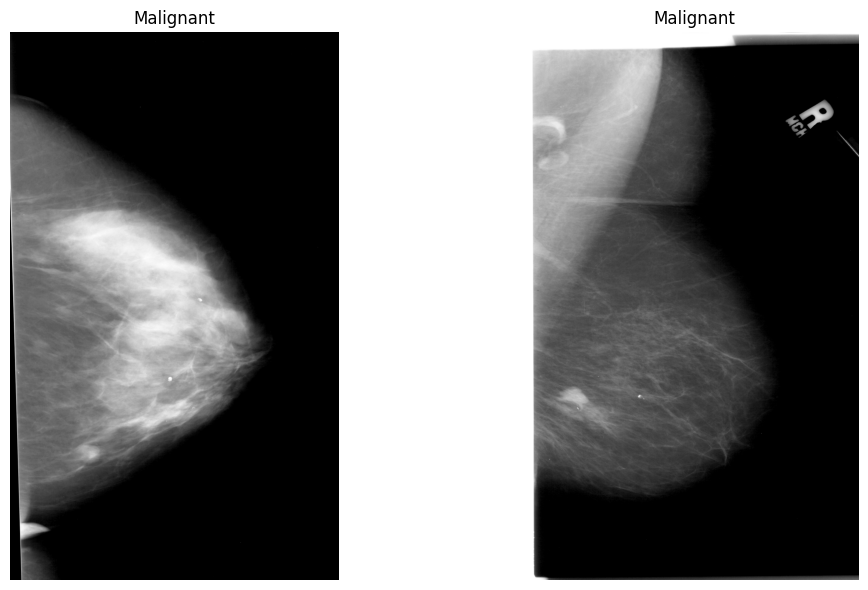

In [22]:
def denormalize_for_display(image_tensor: torch.Tensor) -> np.ndarray:
    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()

    image = (
        image * MAMMOCLIP_STD
    ) + MAMMOCLIP_MEAN

    image = np.clip(image, 0.0, 1.0)

    return image


batch = next(iter(train_loader))

num_images = min(4, len(batch["images"]))

plt.figure(figsize=(12, 6))

for index in range(num_images):
    plt.subplot(1, num_images, index + 1)

    image = denormalize_for_display(
        batch["images"][index]
    )

    plt.imshow(image, cmap="gray")
    plt.title(
        "Malignant"
        if int(batch["labels"][index].item()) == 1
        else "Benign"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

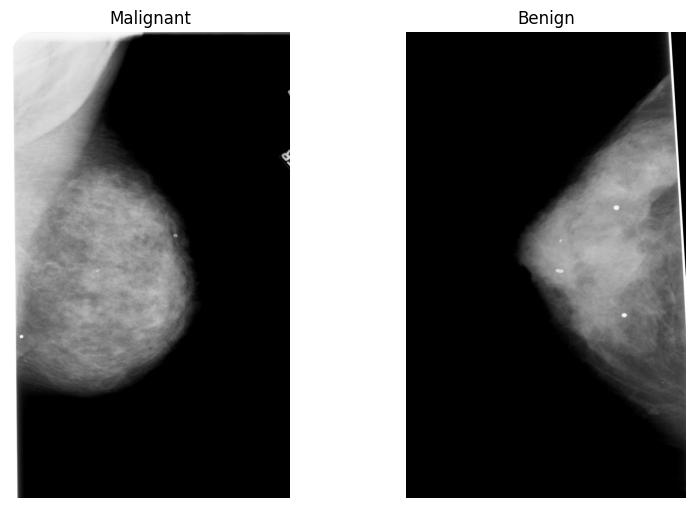

In [23]:
batch = next(iter(train_loader))

num_images = min(8, len(batch["images"]))

plt.figure(figsize=(16, 10))

for index in range(num_images):
    plt.subplot(2, 4, index + 1)

    image = denormalize_for_display(
        batch["images"][index]
    )

    plt.imshow(image, cmap="gray")
    plt.title(
        "Malignant"
        if int(batch["labels"][index].item()) == 1
        else "Benign"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

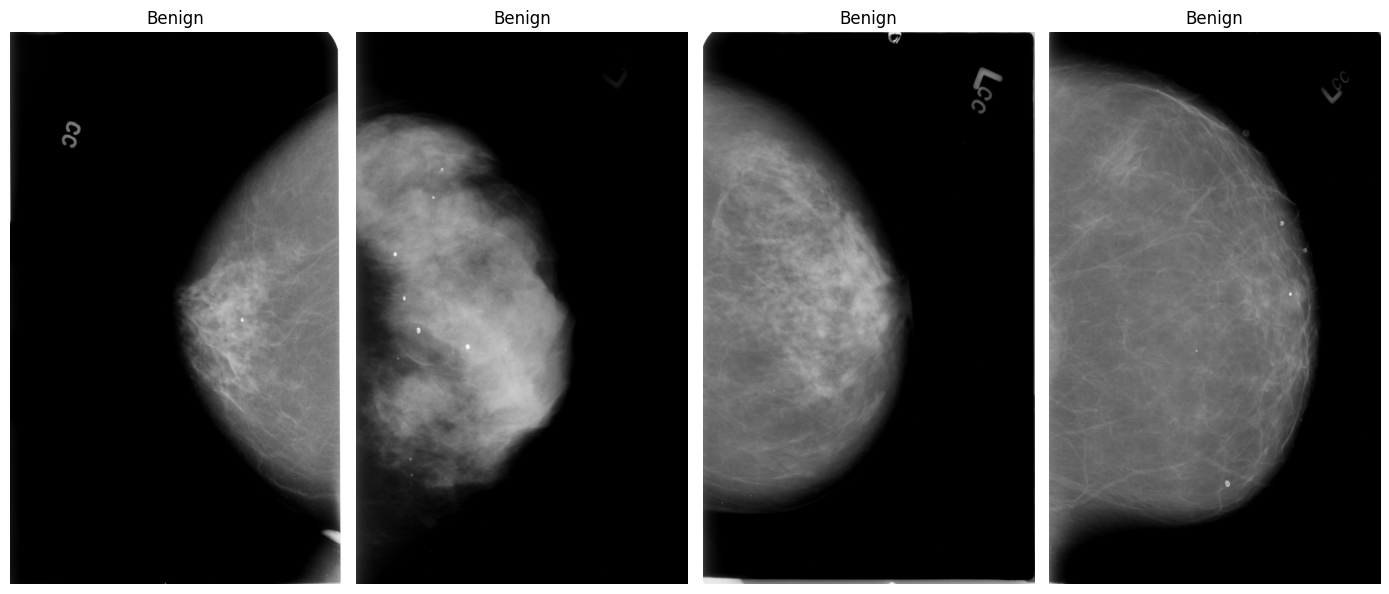

In [24]:
benign_df = train_df[
    train_df["cancer"] == 0
].sample(
    n=4,
    random_state=42,
)

benign_dataset = CBISMammoClipDataset(
    dataframe=benign_df,
    transform=val_transform,
)

benign_loader = DataLoader(
    benign_dataset,
    batch_size=4,
    shuffle=False,
)

benign_batch = next(iter(benign_loader))

plt.figure(figsize=(14, 7))

for index in range(len(benign_batch["images"])):
    plt.subplot(1, 4, index + 1)

    image = denormalize_for_display(
        benign_batch["images"][index]
    )

    plt.imshow(image, cmap="gray")
    plt.title("Benign")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Checkpoint and Mammo-CLIP Teacher**

## **Download the B2 Checkpoint**

In [25]:
from huggingface_hub import hf_hub_download

checkpoint_path = hf_hub_download(
    repo_id="shawn24/Mammo-CLIP",
    filename="Pre-trained-checkpoints/b2-model-best-epoch-10.tar",
    local_dir=str(CHECKPOINT_DIR),
)

checkpoint_path = Path(checkpoint_path)

print("Checkpoint:", checkpoint_path)
print("Exists    :", checkpoint_path.exists())
print("Size MB   :", checkpoint_path.stat().st_size / (1024 ** 2))

Checkpoint: /content/drive/MyDrive/Research/checkpoints/Pre-trained-checkpoints/b2-model-best-epoch-10.tar
Exists    : True
Size MB   : 1336.8689737319946


## **Load Checkpoint**

In [26]:
checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False,
)

print("Checkpoint keys:")
for key in checkpoint.keys():
    print(" -", key)

Checkpoint keys:
 - model
 - optimizer
 - scheduler
 - config
 - epoch
 - train_loss


## **Check the Encoder Configuration**

In [27]:
model_config = checkpoint["config"]["model"]
image_encoder_config = model_config["image_encoder"]

print("Image encoder configuration:")
print(image_encoder_config)

print("\nProjection configuration:")
print(model_config.get("projection_head", "Unavailable"))

Image encoder configuration:
{'source': 'cnn', 'name': 'tf_efficientnetv2-detect', 'pretrained': True, 'model_type': 'cnn'}

Projection configuration:
{'name': 'linear', 'dropout': 0.1, 'proj_dim': 512}


In [28]:
model_state = checkpoint["model"]

encoder_keys = [
    key
    for key in model_state
    if key.startswith("image_encoder.")
]

projection_keys = [
    key
    for key in model_state
    if key.startswith("image_projection.")
]

classifier_keys = [
    key
    for key in model_state
    if key.startswith("classifier.")
]

print("Image encoder tensors :", len(encoder_keys))
print("Image projection tensors:", len(projection_keys))
print("Classifier tensors    :", len(classifier_keys))

print("\nEncoder keys example:")
for key in encoder_keys[:5]:
    print(" -", key)

print("\nProjection keys example:")
for key in projection_keys[:5]:
    print(" -", key)

assert len(encoder_keys) > 0
assert len(projection_keys) > 0

Image encoder tensors : 506
Image projection tensors: 2
Classifier tensors    : 0

Encoder keys example:
 - image_encoder._conv_stem.weight
 - image_encoder._bn0.weight
 - image_encoder._bn0.bias
 - image_encoder._bn0.running_mean
 - image_encoder._bn0.running_var

Projection keys example:
 - image_projection.projection.weight
 - image_projection.projection.bias


## **Import Mammo-CLIP's Components**

In [29]:
import importlib
import importlib.util

# Automatically search for the module’s location to avoid incorrect paths.
module_files = list(
    REPO_ROOT.rglob(
        "breastclip/model/modules/__init__.py"
    )
)

print("Module files found:", len(module_files))

for path in module_files:
    print(" -", path)

if not module_files:
    raise FileNotFoundError(
        "breastclip/model/modules/__init__.py not found. "
        "Check whether the repository has been successfully cloned."
    )

MODULE_INIT = module_files[0]
CODEBASE_DIR = MODULE_INIT.parents[3]

print("\nResolved CODEBASE_DIR:", CODEBASE_DIR)
print("Exists:", CODEBASE_DIR.exists())

if str(CODEBASE_DIR) not in sys.path:
    sys.path.insert(0, str(CODEBASE_DIR))

importlib.invalidate_caches()

print("\nsys.path[0]:", sys.path[0])
print(
    "breastclip spec:",
    importlib.util.find_spec("breastclip")
)
print(
    "modules spec:",
    importlib.util.find_spec(
        "breastclip.model.modules"
    )
)

Module files found: 1
 - /content/Mammo-CLIP/src/codebase/breastclip/model/modules/__init__.py

Resolved CODEBASE_DIR: /content/Mammo-CLIP/src/codebase
Exists: True

sys.path[0]: /content/Mammo-CLIP/src/codebase
breastclip spec: ModuleSpec(name='breastclip', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7b6e3a3a2480>, origin='/content/Mammo-CLIP/src/codebase/breastclip/__init__.py', submodule_search_locations=['/content/Mammo-CLIP/src/codebase/breastclip'])


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


modules spec: ModuleSpec(name='breastclip.model.modules', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7b6e38201520>, origin='/content/Mammo-CLIP/src/codebase/breastclip/model/modules/__init__.py', submodule_search_locations=['/content/Mammo-CLIP/src/codebase/breastclip/model/modules'])


In [30]:
from breastclip.model.modules import (
    LinearClassifier,
    load_image_encoder,
    load_projection_head,
)

print("The Mammo-CLIP import was successful.")

The Mammo-CLIP import was successful.


## **Teacher Wrapper**

In [31]:
class MammoClipTeacher(nn.Module):
    def __init__(
        self,
        checkpoint: dict,
        freeze_encoder: bool = False,
        load_projection: bool = True,
    ):
        super().__init__()

        self.model_config = checkpoint["config"]["model"]
        self.image_encoder_config = self.model_config["image_encoder"]

        # --------------------------------------------------------
        # 1. Build the image encoder from the checkpoint configuration.
        # --------------------------------------------------------
        self.image_encoder = load_image_encoder(
            self.image_encoder_config
        )

        # --------------------------------------------------------
        # 2. Extract the image encoder weight.
        # --------------------------------------------------------
        image_encoder_weights = {
            key.replace("image_encoder.", "", 1): value
            for key, value in checkpoint["model"].items()
            if key.startswith("image_encoder.")
        }

        if not image_encoder_weights:
            raise KeyError(
                "No weights were found with the prefix 'image_encoder.'"
            )

        load_result = self.image_encoder.load_state_dict(
            image_encoder_weights,
            strict=True,
        )

        print("Image encoder loaded:", load_result)

        self.feature_dim = int(self.image_encoder.out_dim)

        # --------------------------------------------------------
        # 3. Official classification head: Linear(out_dim, 1).
        # --------------------------------------------------------
        self.classifier = LinearClassifier(
            feature_dim=self.feature_dim,
            num_class=1,
        )

        # --------------------------------------------------------
        # 4. Projection head CLIP, if available.
        # --------------------------------------------------------
        self.image_projection = None
        self.projection_dim = None

        if (
            load_projection
            and "projection_head" in self.model_config
        ):
            projection_config = self.model_config["projection_head"]

            self.image_projection = load_projection_head(
                embedding_dim=self.feature_dim,
                config_projection_head=projection_config,
            )

            projection_weights = {
                key.replace("image_projection.", "", 1): value
                for key, value in checkpoint["model"].items()
                if key.startswith("image_projection.")
            }

            if projection_weights:
                projection_result = (
                    self.image_projection.load_state_dict(
                        projection_weights,
                        strict=True,
                    )
                )

                print(
                    "Image projection loaded:",
                    projection_result,
                )
            else:
                print(
                    "Warning: The image_projection weight was not found."
                )

            self.projection_dim = int(
                projection_config["proj_dim"]
            )

        self.set_encoder_trainable(
            trainable=not freeze_encoder
        )

    def set_encoder_trainable(
        self,
        trainable: bool,
    ) -> None:
        for parameter in self.image_encoder.parameters():
            parameter.requires_grad = trainable

        if self.image_projection is not None:
            # The projection head is kept frozen.
            for parameter in self.image_projection.parameters():
                parameter.requires_grad = False

        if not trainable:
            self.image_encoder.eval()

    def train(self, mode: bool = True):
        super().train(mode)

        encoder_is_trainable = any(
            parameter.requires_grad
            for parameter in self.image_encoder.parameters()
        )

        # In linear probing, keep the encoder in eval mode
        # so that the BatchNorm statistics remain unchanged.
        if not encoder_is_trainable:
            self.image_encoder.eval()

        # The projection head is always frozen in this design.
        if self.image_projection is not None:
            self.image_projection.eval()

        return self

    def encode_image(
        self,
        images: torch.Tensor,
    ):
        encoder_input = {
            "image": images,
            "breast_clip_train_mode": True,
        }

        pooled_features, raw_features = self.image_encoder(
            encoder_input
        )

        return pooled_features, raw_features

    def forward(
        self,
        images: torch.Tensor,
        return_features: bool = True,
    ):
        pooled_features, raw_features = self.encode_image(
            images
        )

        logits = self.classifier(
            pooled_features
        )

        output = {
            "logits": logits,
        }

        if return_features:
            output["pooled_features"] = pooled_features
            output["raw_features"] = raw_features

            if self.image_projection is not None:
                projected_features = self.image_projection(
                    pooled_features
                )

                projected_features = F.normalize(
                    projected_features,
                    dim=1,
                )

                output["projected_features"] = (
                    projected_features
                )

        return output

## **Build Teacher**

In [32]:
teacher = MammoClipTeacher(
    checkpoint=checkpoint,
    freeze_encoder=True,
    load_projection=True,
)

teacher = teacher.to(DEVICE)

print(teacher)

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b2-8bb594d6.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b2-8bb594d6.pth


100%|██████████| 35.1M/35.1M [00:00<00:00, 86.6MB/s]


<All keys matched successfully>
Loaded pretrained weights for efficientnet-b2
Image encoder loaded: <All keys matched successfully>
Image projection loaded: <All keys matched successfully>
MammoClipTeacher(
  (image_encoder): EfficientNet(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
     

In [33]:
teacher.train()

print("Teacher training mode   :", teacher.training)
print("Encoder training mode   :", teacher.image_encoder.training)
print("Classifier training mode:", teacher.classifier.training)

if teacher.image_projection is not None:
    print(
        "Projection training mode:",
        teacher.image_projection.training,
    )

Teacher training mode   : True
Encoder training mode   : False
Classifier training mode: True
Projection training mode: False


## **Parameter Summary**

In [34]:
def count_parameters(model: nn.Module):
    total = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    return total, trainable


total_params, trainable_params = count_parameters(teacher)

print(f"Feature dimension : {teacher.feature_dim:,}")
print(f"Projection dim    : {teacher.projection_dim}")
print(f"Total parameters  : {total_params:,}")
print(f"Trainable params  : {trainable_params:,}")
print(f"Frozen params     : {total_params - trainable_params:,}")

Feature dimension : 1,408
Projection dim    : 512
Total parameters  : 8,423,811
Trainable params  : 1,409
Frozen params     : 8,422,402


# **Sanity Check**

## **Forward One Batch**

In [35]:
teacher.eval()

batch = next(iter(train_loader))

images = batch["images"].to(
    DEVICE,
    non_blocking=True,
)

labels = batch["labels"].to(
    DEVICE,
    non_blocking=True,
)

with torch.no_grad():
    with torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=USE_AMP,
    ):
        outputs = teacher(
            images,
            return_features=True,
        )

print("Images             :", images.shape)
print("Labels             :", labels.shape)
print("Logits             :", outputs["logits"].shape)
print("Pooled features    :", outputs["pooled_features"].shape)
print("Raw features       :", outputs["raw_features"].shape)

if "projected_features" in outputs:
    print(
        "Projected features :",
        outputs["projected_features"].shape,
    )

Images             : torch.Size([2, 3, 1520, 912])
Labels             : torch.Size([2])
Logits             : torch.Size([2, 1])
Pooled features    : torch.Size([2, 1408])
Raw features       : torch.Size([2, 1408, 48, 29])
Projected features : torch.Size([2, 512])


## **Output Value Check**

In [36]:
for name, tensor in outputs.items():
    print(
        f"{name:20s} | "
        f"shape={tuple(tensor.shape)} | "
        f"dtype={tensor.dtype} | "
        f"finite={torch.isfinite(tensor).all().item()}"
    )

logits               | shape=(2, 1) | dtype=torch.float16 | finite=True
pooled_features      | shape=(2, 1408) | dtype=torch.float16 | finite=True
raw_features         | shape=(2, 1408, 48, 29) | dtype=torch.float16 | finite=True
projected_features   | shape=(2, 512) | dtype=torch.float32 | finite=True


## **Early Probability**

In [37]:
probabilities = torch.sigmoid(
    outputs["logits"].float()
).squeeze(1)

print("Labels       :", labels.detach().cpu().numpy())
print("Logits       :", outputs["logits"].detach().cpu().flatten().numpy())
print("Probabilities:", probabilities.detach().cpu().numpy())

Labels       : [0. 1.]
Logits       : [-0.2241 -0.1387]
Probabilities: [0.44420308 0.46538746]


## **BCE loss of one batch**

In [38]:
criterion = nn.BCEWithLogitsLoss()

loss = criterion(
    outputs["logits"].float().squeeze(1),
    labels.float(),
)

print("Sanity-check BCE loss:", float(loss.item()))

assert torch.isfinite(loss), (
    "The loss contains NaN or Inf."
)

Sanity-check BCE loss: 0.6761186122894287


## **One mini-batch of backward passes**

In [39]:
teacher.train()

# The encoder remains in eval mode because it is frozen.
teacher.image_encoder.eval()

if teacher.image_projection is not None:
    teacher.image_projection.eval()

teacher.classifier.train()
teacher.zero_grad(set_to_none=True)

batch = next(iter(train_loader))

images = batch["images"].to(
    DEVICE,
    non_blocking=True,
)

labels = batch["labels"].to(
    DEVICE,
    non_blocking=True,
)

with torch.autocast(
    device_type=DEVICE.type,
    dtype=torch.float16,
    enabled=USE_AMP,
):
    outputs = teacher(
        images,
        return_features=False,
    )

    loss = criterion(
        outputs["logits"].float().squeeze(1),
        labels.float(),
    )

loss.backward()

classifier_grad_norm = 0.0

for parameter in teacher.classifier.parameters():
    if parameter.grad is not None:
        classifier_grad_norm += (
            parameter.grad.detach().norm().item()
        )

print("Loss                    :", float(loss.item()))
print("Classifier gradient norm:", classifier_grad_norm)

assert classifier_grad_norm > 0, (
    "The classifier does not accept gradients."
)

print("The forward and backward sanity checks were successful.")

Loss                    : 0.7528833150863647
Classifier gradient norm: 3.0924932956695557
The forward and backward sanity checks were successful.


## **Ensure that the encoder does not receive a gradient**

In [40]:
encoder_has_gradient = any(
    parameter.grad is not None
    for parameter in teacher.image_encoder.parameters()
)

classifier_has_gradient = any(
    parameter.grad is not None
    for parameter in teacher.classifier.parameters()
)

projection_has_gradient = (
    any(
        parameter.grad is not None
        for parameter in teacher.image_projection.parameters()
    )
    if teacher.image_projection is not None
    else False
)

print("Encoder has gradient   :", encoder_has_gradient)
print("Projection has gradient:", projection_has_gradient)
print("Classifier has gradient:", classifier_has_gradient)

assert encoder_has_gradient is False
assert projection_has_gradient is False
assert classifier_has_gradient is True

print("Linear probing gradient configuration is correct.")

Encoder has gradient   : False
Projection has gradient: False
Classifier has gradient: True
Linear probing gradient configuration is correct.


## **Clear the memory**

In [41]:
# Remove any remaining gradients from the backward sanity check
teacher.zero_grad(set_to_none=True)

# Delete only temporary tensor variables
temporary_variables = [
    "batch",
    "images",
    "labels",
    "outputs",
    "loss",
    "probabilities",
]

for variable_name in temporary_variables:
    globals().pop(variable_name, None)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    allocated_gb = (
        torch.cuda.memory_allocated() / 1024**3
    )
    reserved_gb = (
        torch.cuda.memory_reserved() / 1024**3
    )

    print(f"GPU allocated: {allocated_gb:.3f} GB")
    print(f"GPU reserved : {reserved_gb:.3f} GB")

print("Temporary sanity-check tensors cleaned.")

GPU allocated: 0.049 GB
GPU reserved : 0.100 GB
Temporary sanity-check tensors cleaned.


# **Linear Probing Mammo-CLIP B2**

## **Training Configuration**

In [42]:
LINEAR_PROBE_EPOCHS = 10
LINEAR_PROBE_LR = 1e-3
WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 3
MIN_IMPROVEMENT = 1e-4

CLASSIFICATION_THRESHOLD = 0.5
MAX_GRAD_NORM = 5.0

USE_AMP = DEVICE.type == "cuda"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_LINEAR_PROBE_PATH = (
    OUTPUT_DIR /
    "mammoclip_b2_linear_probe_best.pt"
)

LINEAR_PROBE_HISTORY_PATH = (
    OUTPUT_DIR /
    "mammoclip_b2_linear_probe_history.csv"
)

print("Linear probing configuration")
print("-" * 40)
print("Epochs              :", LINEAR_PROBE_EPOCHS)
print("Learning rate       :", LINEAR_PROBE_LR)
print("Weight decay        :", WEIGHT_DECAY)
print("Early-stop patience :", EARLY_STOPPING_PATIENCE)
print("Decision threshold  :", CLASSIFICATION_THRESHOLD)
print("AMP enabled         :", USE_AMP)
print("Best checkpoint     :", BEST_LINEAR_PROBE_PATH)

Linear probing configuration
----------------------------------------
Epochs              : 10
Learning rate       : 0.001
Weight decay        : 0.0001
Early-stop patience : 3
Decision threshold  : 0.5
AMP enabled         : True
Best checkpoint     : /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/mammoclip_b2_linear_probe_best.pt


## **Ensure that the frozen configuration is correct**

In [43]:
# Make sure the encoder remains frozen.
for parameter in teacher.image_encoder.parameters():
    parameter.requires_grad = False

# The projection head also remains frozen.
if teacher.image_projection is not None:
    for parameter in teacher.image_projection.parameters():
        parameter.requires_grad = False

# Only trainable classifiers.
for parameter in teacher.classifier.parameters():
    parameter.requires_grad = True

teacher = teacher.to(DEVICE)
teacher.train()

total_parameters = sum(
    parameter.numel()
    for parameter in teacher.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in teacher.parameters()
    if parameter.requires_grad
)

print("Total parameters    :", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")

print()
print("Teacher mode   :", teacher.training)
print("Encoder mode   :", teacher.image_encoder.training)
print("Classifier mode:", teacher.classifier.training)

if teacher.image_projection is not None:
    print(
        "Projection mode:",
        teacher.image_projection.training,
    )

assert trainable_parameters == 1409
assert teacher.image_encoder.training is False
assert teacher.classifier.training is True

if teacher.image_projection is not None:
    assert teacher.image_projection.training is False

print("\nLinear probing configuration verified.")

Total parameters    : 8,423,811
Trainable parameters: 1,409

Teacher mode   : True
Encoder mode   : False
Classifier mode: True
Projection mode: False

Linear probing configuration verified.


## **The logit function**

In [44]:
def extract_logits(model_output):
    if isinstance(model_output, dict):
        if "logits" not in model_output:
            raise KeyError(
                "Model output dictionary does not contain 'logits'."
            )

        return model_output["logits"]

    return model_output

## **Metric evaluation function**

In [45]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def calculate_binary_metrics(
    labels,
    probabilities,
    threshold=0.5,
):
    labels = np.asarray(labels).astype(np.int64)
    probabilities = np.asarray(probabilities).astype(
        np.float64
    )

    predictions = (
        probabilities >= threshold
    ).astype(np.int64)

    accuracy = accuracy_score(
        labels,
        predictions,
    )

    balanced_accuracy = balanced_accuracy_score(
        labels,
        predictions,
    )

    precision = precision_score(
        labels,
        predictions,
        zero_division=0,
    )

    sensitivity = recall_score(
        labels,
        predictions,
        zero_division=0,
    )

    f1 = f1_score(
        labels,
        predictions,
        zero_division=0,
    )

    confusion = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    )

    tn, fp, fn, tp = confusion.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    if np.unique(labels).size == 2:
        roc_auc = roc_auc_score(
            labels,
            probabilities,
        )
    else:
        roc_auc = np.nan

    return {
        "roc_auc": float(roc_auc),
        "accuracy": float(accuracy),
        "balanced_accuracy": float(
            balanced_accuracy
        ),
        "precision": float(precision),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "f1": float(f1),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

## **One-epoch training function**

In [46]:
from tqdm.auto import tqdm


def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    scaler,
    device,
    threshold=0.5,
):
    model.train()

    # The `train()` method in `MammoClipTeacher`
    # must keep the encoder in eval mode.
    assert model.image_encoder.training is False

    if model.image_projection is not None:
        assert model.image_projection.training is False

    running_loss = 0.0
    sample_count = 0

    all_labels = []
    all_probabilities = []

    progress_bar = tqdm(
        data_loader,
        desc="Training",
        leave=False,
    )

    for batch in progress_bar:
        images = batch["images"].to(
            device,
            non_blocking=True,
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True,
        ).float().view(-1)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            model_output = model(images)
            logits = extract_logits(
                model_output
            ).view(-1)

            loss = criterion(
                logits,
                labels,
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.classifier.parameters(),
            max_norm=MAX_GRAD_NORM,
        )

        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)

        running_loss += (
            loss.detach().item() * batch_size
        )
        sample_count += batch_size

        probabilities = torch.sigmoid(
            logits.detach()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / sample_count

    metrics = calculate_binary_metrics(
        labels=all_labels,
        probabilities=all_probabilities,
        threshold=threshold,
    )

    metrics["loss"] = float(epoch_loss)

    return metrics

## **Validation Function**

In [47]:
@torch.inference_mode()
def validate_one_epoch(
    model,
    data_loader,
    criterion,
    device,
    threshold=0.5,
):
    model.eval()

    running_loss = 0.0
    sample_count = 0

    all_labels = []
    all_probabilities = []

    progress_bar = tqdm(
        data_loader,
        desc="Validation",
        leave=False,
    )

    for batch in progress_bar:
        images = batch["images"].to(
            device,
            non_blocking=True,
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True,
        ).float().view(-1)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            model_output = model(images)
            logits = extract_logits(
                model_output
            ).view(-1)

            loss = criterion(
                logits,
                labels,
            )

        batch_size = labels.size(0)

        running_loss += (
            loss.detach().item() * batch_size
        )
        sample_count += batch_size

        probabilities = torch.sigmoid(
            logits
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

    epoch_loss = running_loss / sample_count

    metrics = calculate_binary_metrics(
        labels=all_labels,
        probabilities=all_probabilities,
        threshold=threshold,
    )

    metrics["loss"] = float(epoch_loss)

    return metrics

## **Loss, optimizer, scheduler, and AMP scaler**

In [48]:
criterion = nn.BCEWithLogitsLoss()

trainable_parameters = [
    parameter
    for parameter in teacher.parameters()
    if parameter.requires_grad
]

assert (
    sum(
        parameter.numel()
        for parameter in trainable_parameters
    )
    == 1409
)

optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=LINEAR_PROBE_LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
)

try:
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )
except TypeError:
    scaler = torch.cuda.amp.GradScaler(
        enabled=USE_AMP,
    )

print("Criterion :", criterion)
print("Optimizer :", optimizer.__class__.__name__)
print("Scheduler :", scheduler.__class__.__name__)
print("AMP       :", USE_AMP)

Criterion : BCEWithLogitsLoss()
Optimizer : AdamW
Scheduler : ReduceLROnPlateau
AMP       : True


## **Execute linear probing**

In [49]:
import time

history = []

best_val_auc = -np.inf
best_epoch = 0
epochs_without_improvement = 0

training_start_time = time.time()

for epoch in range(
    1,
    LINEAR_PROBE_EPOCHS + 1,
):
    epoch_start_time = time.time()

    current_lr = optimizer.param_groups[0]["lr"]

    train_metrics = train_one_epoch(
        model=teacher,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=DEVICE,
        threshold=CLASSIFICATION_THRESHOLD,
    )

    val_metrics = validate_one_epoch(
        model=teacher,
        data_loader=val_loader,
        criterion=criterion,
        device=DEVICE,
        threshold=CLASSIFICATION_THRESHOLD,
    )

    val_auc_for_scheduler = val_metrics["roc_auc"]

    if np.isnan(val_auc_for_scheduler):
        val_auc_for_scheduler = val_metrics[
            "balanced_accuracy"
        ]

    scheduler.step(val_auc_for_scheduler)

    epoch_duration = time.time() - epoch_start_time

    epoch_record = {
        "epoch": epoch,
        "learning_rate": current_lr,
        "train_loss": train_metrics["loss"],
        "train_roc_auc": train_metrics["roc_auc"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "train_sensitivity": train_metrics[
            "sensitivity"
        ],
        "train_specificity": train_metrics[
            "specificity"
        ],
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_accuracy": val_metrics["accuracy"],
        "val_balanced_accuracy": val_metrics[
            "balanced_accuracy"
        ],
        "val_f1": val_metrics["f1"],
        "val_sensitivity": val_metrics[
            "sensitivity"
        ],
        "val_specificity": val_metrics[
            "specificity"
        ],
        "epoch_seconds": epoch_duration,
    }

    history.append(epoch_record)

    print(
        f"Epoch {epoch:02d}/"
        f"{LINEAR_PROBE_EPOCHS:02d} | "
        f"LR {current_lr:.2e} | "
        f"Train Loss {train_metrics['loss']:.4f} | "
        f"Train AUC {train_metrics['roc_auc']:.4f} | "
        f"Val Loss {val_metrics['loss']:.4f} | "
        f"Val AUC {val_metrics['roc_auc']:.4f} | "
        f"Val Sens {val_metrics['sensitivity']:.4f} | "
        f"Val Spec {val_metrics['specificity']:.4f} | "
        f"{epoch_duration / 60:.1f} min"
    )

    current_val_auc = val_metrics["roc_auc"]

    if np.isnan(current_val_auc):
        current_val_auc = val_metrics[
            "balanced_accuracy"
        ]

    improved = (
        current_val_auc
        > best_val_auc + MIN_IMPROVEMENT
    )

    if improved:
        best_val_auc = current_val_auc
        best_epoch = epoch
        epochs_without_improvement = 0

        checkpoint_payload = {
            "epoch": epoch,
            "model_state_dict": (
                teacher.state_dict()
            ),
            "optimizer_state_dict": (
                optimizer.state_dict()
            ),
            "scheduler_state_dict": (
                scheduler.state_dict()
            ),
            "val_metrics": val_metrics,
            "train_metrics": train_metrics,
            "best_val_auc": best_val_auc,
            "feature_dim": teacher.feature_dim,
            "projection_dim": (
                teacher.projection_dim
            ),
            "threshold": (
                CLASSIFICATION_THRESHOLD
            ),
            "training_stage": (
                "linear_probe"
            ),
        }

        torch.save(
            checkpoint_payload,
            BEST_LINEAR_PROBE_PATH,
        )

        print(
            f"  ✓ Best checkpoint saved "
            f"(Val AUC: {best_val_auc:.4f})"
        )

    else:
        epochs_without_improvement += 1

        print(
            "  No validation AUC improvement "
            f"for {epochs_without_improvement} "
            "epoch(s)."
        )

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        LINEAR_PROBE_HISTORY_PATH,
        index=False,
    )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "\nEarly stopping activated at "
            f"epoch {epoch}."
        )
        break

total_training_time = (
    time.time() - training_start_time
)

print("\nLinear probing completed.")
print("Best epoch   :", best_epoch)
print("Best val AUC :", f"{best_val_auc:.4f}")
print(
    "Training time:",
    f"{total_training_time / 60:.2f} minutes",
)
print("Checkpoint   :", BEST_LINEAR_PROBE_PATH)
print("History CSV  :", LINEAR_PROBE_HISTORY_PATH)

Training:   0%|          | 0/1241 [00:00<?, ?it/s]

Validation:   0%|          | 0/311 [00:00<?, ?it/s]

Epoch 01/10 | LR 1.00e-03 | Train Loss 0.6322 | Train AUC 0.6838 | Val Loss 0.6671 | Val AUC 0.6450 | Val Sens 0.4146 | Val Spec 0.7216 | 9.6 min
  ✓ Best checkpoint saved (Val AUC: 0.6450)


Training:   0%|          | 0/1241 [00:00<?, ?it/s]

Validation:   0%|          | 0/311 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/311 [00:00<?, ?it/s]

Epoch 09/10 | LR 1.00e-03 | Train Loss 0.5188 | Train AUC 0.8179 | Val Loss 0.6630 | Val AUC 0.7093 | Val Sens 0.4111 | Val Spec 0.8263 | 9.0 min
  No validation AUC improvement for 1 epoch(s).


Training:   0%|          | 0/1241 [00:00<?, ?it/s]

Validation:   0%|          | 0/311 [00:00<?, ?it/s]

Epoch 10/10 | LR 1.00e-03 | Train Loss 0.5143 | Train AUC 0.8201 | Val Loss 0.6345 | Val AUC 0.7186 | Val Sens 0.4704 | Val Spec 0.7844 | 9.1 min
  ✓ Best checkpoint saved (Val AUC: 0.7186)

Linear probing completed.
Best epoch   : 10
Best val AUC : 0.7186
Training time: 91.13 minutes
Checkpoint   : /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/mammoclip_b2_linear_probe_best.pt
History CSV  : /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/mammoclip_b2_linear_probe_history.csv


## **Reload the best checkpoint**

In [50]:
best_linear_checkpoint = torch.load(
    BEST_LINEAR_PROBE_PATH,
    map_location=DEVICE,
    weights_only=False,
)

teacher.load_state_dict(
    best_linear_checkpoint["model_state_dict"]
)

teacher = teacher.to(DEVICE)
teacher.eval()

print(
    "Loaded best epoch:",
    best_linear_checkpoint["epoch"],
)

print(
    "Loaded best validation AUC:",
    best_linear_checkpoint["best_val_auc"],
)

print(
    "Validation metrics:",
    best_linear_checkpoint["val_metrics"],
)

Loaded best epoch: 10
Loaded best validation AUC: 0.7186046026414071
Validation metrics: {'roc_auc': 0.7186046026414071, 'accuracy': 0.6392914653784219, 'balanced_accuracy': 0.6274072064929375, 'precision': 0.6521739130434783, 'sensitivity': 0.47038327526132406, 'specificity': 0.7844311377245509, 'f1': 0.5465587044534413, 'tn': 262, 'fp': 72, 'fn': 152, 'tp': 135, 'loss': 0.6344770816141281}


## **Show training history**

In [51]:
history_df = pd.read_csv(
    LINEAR_PROBE_HISTORY_PATH
)

display(history_df.round(4))

,epoch,learning_rate,train_loss,train_roc_auc,train_accuracy,train_f1,train_sensitivity,train_specificity,val_loss,val_roc_auc,val_accuracy,val_balanced_accuracy,val_f1,val_sensitivity,val_specificity,epoch_seconds
0,1,0.001,0.6322,0.6838,0.6410,0.5228,0.4485,0.7912,0.6671,0.6450,0.5797,0.5681,0.4770,0.4146,0.7216,575.0293
1,2,0.001,0.5917,0.7415,0.6696,0.5892,0.5404,0.7704,0.6472,0.6724,0.6200,0.6173,0.5860,0.5819,0.6527,546.5288
2,3,0.001,0.5651,0.7756,0.7119,0.6490,0.6075,0.7934,0.6425,0.6877,0.6216,0.6117,0.5401,0.4808,0.7425,542.1246
3,4,0.001,0.5501,0.7895,0.7103,0.6522,0.6195,0.7812,0.6480,0.6995,0.6087,0.5928,0.4752,0.3833,0.8024,541.3621
4,5,0.001,0.5458,0.7938,0.7220,0.6673,0.6360,0.7891,0.6400,0.7010,0.6296,0.6206,0.5560,0.5017,0.7395,544.1735
5,6,0.001,0.5358,0.8023,0.7252,0.6693,0.6342,0.7963,0.6363,0.7082,0.6377,0.6264,0.5491,0.4774,0.7754,543.5574
6,7,0.001,0.5321,0.8069,0.7337,0.6851,0.6608,0.7905,0.6239,0.7139,0.6506,0.6435,0.5929,0.5505,0.7365,541.7994
7,8,0.001,0.5263,0.8110,0.7397,0.6935,0.6719,0.7927,0.6514,0.7149,0.6329,0.6175,0.5107,0.4146,0.8204,541.5500
8,9,0.001,0.5188,0.8179,0.7442,0.6934,0.6599,0.8099,0.6630,0.7093,0.6345,0.6187,0.5097,0.4111,0.8263,539.8238
9,10,0.001,0.5143,0.8201,0.7429,0.6973,0.6756,0.7956,0.6345,0.7186,0.6393,0.6274,0.5466,0.4704,0.7844,546.2742


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


# **Linear Probing Evaluation**

## **Retrieve the validation set predictions**

In [52]:
@torch.inference_mode()
def collect_predictions(
    model,
    data_loader,
    device,
):
    model.eval()

    all_labels = []
    all_logits = []
    all_probabilities = []
    all_paths = []
    all_patients = []

    progress_bar = tqdm(
        data_loader,
        desc="Collecting predictions",
        leave=False,
    )

    for batch in progress_bar:
        images = batch["images"].to(
            device,
            non_blocking=True,
        )

        labels = batch["labels"].float().view(-1)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            model_output = model(images)

            logits = extract_logits(
                model_output
            ).view(-1)

        probabilities = torch.sigmoid(logits)

        all_labels.extend(
            labels.cpu().numpy().tolist()
        )
        all_logits.extend(
            logits.float().cpu().numpy().tolist()
        )
        all_probabilities.extend(
            probabilities.float().cpu().numpy().tolist()
        )

        batch_size = labels.size(0)

        if "path" in batch:
            all_paths.extend(list(batch["path"]))
        else:
            all_paths.extend(
                [None] * batch_size
            )

        if "patient" in batch:
            all_patients.extend(
                list(batch["patient"])
            )
        else:
            all_patients.extend(
                [None] * batch_size
            )

    prediction_df = pd.DataFrame({
        "image_path": all_paths,
        "patient_id": all_patients,
        "label": np.asarray(
            all_labels,
            dtype=np.int64,
        ),
        "logit": np.asarray(
            all_logits,
            dtype=np.float32,
        ),
        "probability": np.asarray(
            all_probabilities,
            dtype=np.float32,
        ),
    })

    return prediction_df


val_prediction_df = collect_predictions(
    model=teacher,
    data_loader=val_loader,
    device=DEVICE,
)

print("Validation predictions:", len(val_prediction_df))
print(
    val_prediction_df[
        ["label", "probability"]
    ].head()
)

assert val_prediction_df["label"].nunique() == 2
assert val_prediction_df["probability"].between(
    0,
    1,
).all()

Validation predictions: 621
   label  probability
0      0     0.468994
1      0     0.363525
2      0     0.293701
3      1     0.225464
4      0     0.067078


## **ROC and Precision–Recall curve**

In [53]:
from sklearn.metrics import (
    auc,
    precision_recall_curve,
    roc_curve,
)

labels = val_prediction_df["label"].to_numpy()
probabilities = val_prediction_df[
    "probability"
].to_numpy()

fpr, tpr, roc_thresholds = roc_curve(
    labels,
    probabilities,
)

roc_auc_value = auc(fpr, tpr)

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        labels,
        probabilities,
    )
)

pr_auc_value = auc(
    recall_curve,
    precision_curve,
)

print("Validation ROC-AUC:", f"{roc_auc_value:.4f}")
print("Validation PR-AUC :", f"{pr_auc_value:.4f}")

Validation ROC-AUC: 0.7186
Validation PR-AUC : 0.6492


In [58]:
from sklearn.metrics import average_precision_score

average_precision = average_precision_score(
    labels,
    probabilities,
)

print(
    "Validation Average Precision:",
    f"{average_precision:.4f}",
)

Validation Average Precision: 0.6514


### **ROC Curve**

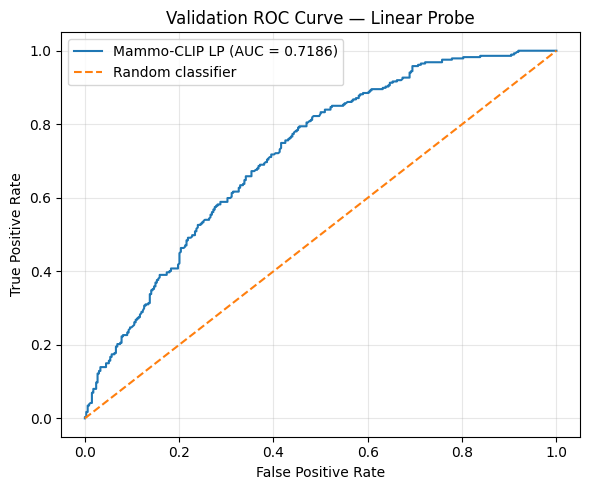

Saved: /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/linear_probe_validation_roc_curve.png


In [54]:
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Mammo-CLIP LP (AUC = {roc_auc_value:.4f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve — Linear Probe")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

ROC_CURVE_PATH = (
    OUTPUT_DIR /
    "linear_probe_validation_roc_curve.png"
)

plt.savefig(
    ROC_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", ROC_CURVE_PATH)

### **Precision-Recall Graph**

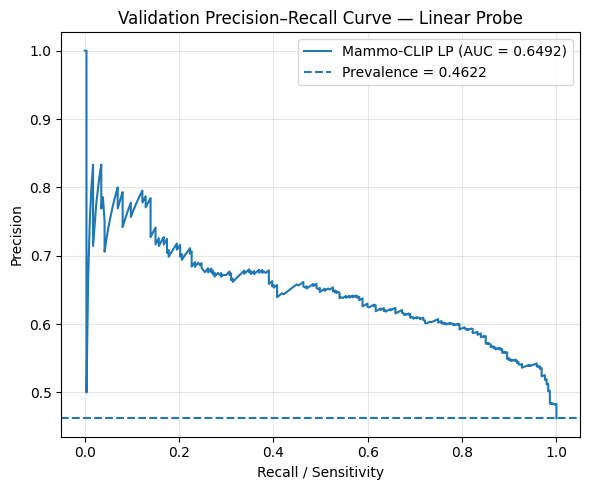

Saved: /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/linear_probe_validation_pr_curve.png


In [55]:
plt.figure(figsize=(6, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Mammo-CLIP LP (AUC = {pr_auc_value:.4f})",
)

positive_prevalence = labels.mean()

plt.axhline(
    positive_prevalence,
    linestyle="--",
    label=f"Prevalence = {positive_prevalence:.4f}",
)

plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title(
    "Validation Precision–Recall Curve — Linear Probe"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

PR_CURVE_PATH = (
    OUTPUT_DIR /
    "linear_probe_validation_pr_curve.png"
)

plt.savefig(
    PR_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", PR_CURVE_PATH)

## **Determine the optimal threshold**

In [56]:
youden_j = tpr - fpr
best_threshold_index = np.argmax(youden_j)

optimal_threshold = float(
    roc_thresholds[best_threshold_index]
)

optimal_sensitivity = float(
    tpr[best_threshold_index]
)

optimal_specificity = float(
    1.0 - fpr[best_threshold_index]
)

print(
    "Optimal threshold:",
    f"{optimal_threshold:.4f}",
)
print(
    "Sensitivity at optimal threshold:",
    f"{optimal_sensitivity:.4f}",
)
print(
    "Specificity at optimal threshold:",
    f"{optimal_specificity:.4f}",
)
print(
    "Youden's J:",
    f"{youden_j[best_threshold_index]:.4f}",
)

Optimal threshold: 0.2944
Sensitivity at optimal threshold: 0.7944
Specificity at optimal threshold: 0.5449
Youden's J: 0.3393


## **Compare the threshold of 0.5 with the optimal threshold**

In [57]:
metrics_threshold_05 = calculate_binary_metrics(
    labels=labels,
    probabilities=probabilities,
    threshold=0.5,
)

metrics_optimal = calculate_binary_metrics(
    labels=labels,
    probabilities=probabilities,
    threshold=optimal_threshold,
)

comparison_df = pd.DataFrame([
    {
        "threshold_type": "Default 0.5",
        "threshold": 0.5,
        **metrics_threshold_05,
    },
    {
        "threshold_type": "Youden optimal",
        "threshold": optimal_threshold,
        **metrics_optimal,
    },
])

display(comparison_df.round(4))

,threshold_type,threshold,roc_auc,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,tn,fp,fn,tp
0,Default 0.5,0.5000,0.7186,0.6393,0.6274,0.6522,0.4704,0.7844,0.5466,262,72,152,135
1,Youden optimal,0.2944,0.7186,0.6602,0.6697,0.6000,0.7944,0.5449,0.6837,182,152,59,228


## **Confusion Matrix & Classification Report**

                        precision    recall  f1-score   support

Benign / Non-malignant     0.7552    0.5449    0.6330       334
             Malignant     0.6000    0.7944    0.6837       287

              accuracy                         0.6602       621
             macro avg     0.6776    0.6697    0.6584       621
          weighted avg     0.6835    0.6602    0.6564       621



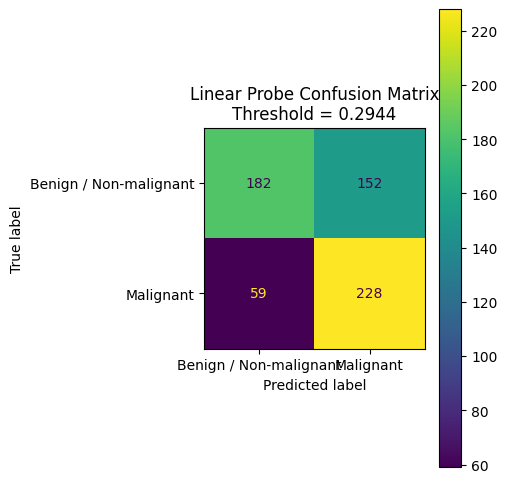

Saved: /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/linear_probe_validation_confusion_matrix.png


In [59]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)
import matplotlib.pyplot as plt


optimal_predictions = (
    probabilities >= optimal_threshold
).astype(np.int64)

print(
    classification_report(
        labels,
        optimal_predictions,
        target_names=[
            "Benign / Non-malignant",
            "Malignant",
        ],
        digits=4,
        zero_division=0,
    )
)

fig, ax = plt.subplots(figsize=(5, 5))

ConfusionMatrixDisplay.from_predictions(
    labels,
    optimal_predictions,
    display_labels=[
        "Benign / Non-malignant",
        "Malignant",
    ],
    values_format="d",
    ax=ax,
)

ax.set_title(
    "Linear Probe Confusion Matrix\n"
    f"Threshold = {optimal_threshold:.4f}"
)

plt.tight_layout()

CONFUSION_MATRIX_PATH = (
    OUTPUT_DIR
    / "linear_probe_validation_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", CONFUSION_MATRIX_PATH)

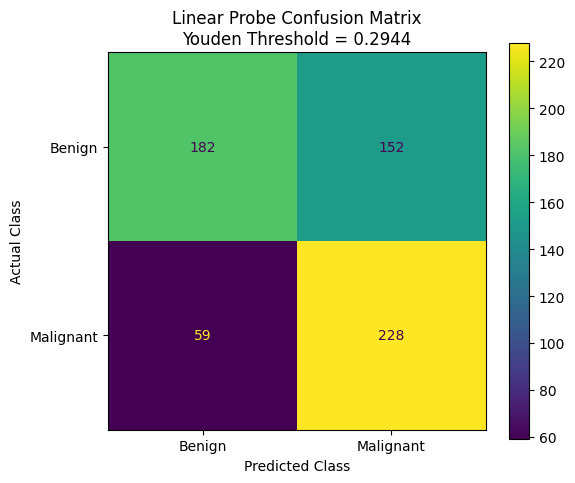

In [60]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    labels,
    optimal_predictions,
    display_labels=["Benign", "Malignant"],
    values_format="d",
    ax=ax,
)

ax.set_title(
    "Linear Probe Confusion Matrix\n"
    f"Youden Threshold = {optimal_threshold:.4f}"
)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## **Save all results**

In [61]:
import json


val_prediction_df[
    "prediction_threshold_05"
] = (
    val_prediction_df["probability"] >= 0.5
).astype(np.int64)

val_prediction_df[
    "prediction_youden"
] = (
    val_prediction_df["probability"]
    >= optimal_threshold
).astype(np.int64)

VAL_PREDICTION_PATH = (
    OUTPUT_DIR
    / "linear_probe_validation_predictions.csv"
)

THRESHOLD_COMPARISON_PATH = (
    OUTPUT_DIR
    / "linear_probe_threshold_comparison.csv"
)

EVALUATION_SUMMARY_PATH = (
    OUTPUT_DIR
    / "linear_probe_evaluation_summary.json"
)

val_prediction_df.to_csv(
    VAL_PREDICTION_PATH,
    index=False,
)

comparison_df.to_csv(
    THRESHOLD_COMPARISON_PATH,
    index=False,
)

evaluation_summary = {
    "model": "Mammo-CLIP B2",
    "training_stage": "linear_probe",
    "best_epoch": int(
        best_linear_checkpoint["epoch"]
    ),
    "validation_samples": int(len(labels)),
    "positive_prevalence": float(
        labels.mean()
    ),
    "validation_roc_auc": float(
        roc_auc_value
    ),
    "validation_pr_auc_trapezoidal": float(
        pr_auc_value
    ),
    "validation_average_precision": float(
        average_precision
    ),
    "default_threshold": 0.5,
    "youden_threshold": float(
        optimal_threshold
    ),
    "youden_j": float(
        youden_j[best_threshold_index]
    ),
    "metrics_threshold_05": (
        metrics_threshold_05
    ),
    "metrics_youden_threshold": (
        metrics_optimal
    ),
}

with open(
    EVALUATION_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        evaluation_summary,
        file,
        indent=2,
    )

print("Predictions :", VAL_PREDICTION_PATH)
print("Comparison  :", THRESHOLD_COMPARISON_PATH)
print("Summary     :", EVALUATION_SUMMARY_PATH)

Predictions : /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/linear_probe_validation_predictions.csv
Comparison  : /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/linear_probe_threshold_comparison.csv
Summary     : /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/linear_probe_evaluation_summary.json


# **Partial Fine-Tuning Teacher**

## Fine-tuning configuration

In [62]:
# import gc
# import time
# from pathlib import Path

# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn


FINETUNE_EPOCHS = 8

ENCODER_LEARNING_RATE = 1e-5
CLASSIFIER_LEARNING_RATE = 1e-4
FINETUNE_WEIGHT_DECAY = 1e-4

FINETUNE_LAST_N_BLOCKS = 2
GRADIENT_ACCUMULATION_STEPS = 4
FINETUNE_MAX_GRAD_NORM = 5.0

FINETUNE_PATIENCE = 3
FINETUNE_MIN_IMPROVEMENT = 1e-4

FINETUNE_THRESHOLD = 0.5

BEST_FINETUNE_PATH = (
    OUTPUT_DIR
    / "mammoclip_b2_partial_finetune_best.pt"
)

FINETUNE_HISTORY_PATH = (
    OUTPUT_DIR
    / "mammoclip_b2_partial_finetune_history.csv"
)

print("Partial fine-tuning configuration")
print("-" * 45)
print("Maximum epochs          :", FINETUNE_EPOCHS)
print("Trainable final blocks  :", FINETUNE_LAST_N_BLOCKS)
print("Encoder learning rate   :", ENCODER_LEARNING_RATE)
print("Classifier learning rate:", CLASSIFIER_LEARNING_RATE)
print("Weight decay            :", FINETUNE_WEIGHT_DECAY)
print(
    "Gradient accumulation   :",
    GRADIENT_ACCUMULATION_STEPS,
)
print("AMP enabled             :", USE_AMP)
print("Best checkpoint         :", BEST_FINETUNE_PATH)

Partial fine-tuning configuration
---------------------------------------------
Maximum epochs          : 8
Trainable final blocks  : 2
Encoder learning rate   : 1e-05
Classifier learning rate: 0.0001
Weight decay            : 0.0001
Gradient accumulation   : 4
AMP enabled             : True
Best checkpoint         : /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/mammoclip_b2_partial_finetune_best.pt


## **Reload the best linear probe checkpoint**

In [63]:
best_linear_checkpoint = torch.load(
    BEST_LINEAR_PROBE_PATH,
    map_location="cpu",
    weights_only=False,
)

teacher.load_state_dict(
    best_linear_checkpoint["model_state_dict"],
    strict=True,
)

teacher = teacher.to(DEVICE)

print(
    "Starting from linear-probe epoch:",
    best_linear_checkpoint["epoch"],
)
print(
    "Starting validation ROC-AUC:",
    f"{best_linear_checkpoint['best_val_auc']:.4f}",
)

Starting from linear-probe epoch: 10
Starting validation ROC-AUC: 0.7186


## **Check the structure of the image encoder**

In [64]:
print("Image encoder type:")
print(type(teacher.image_encoder))

print("\nRelevant attributes:")
for attribute_name in [
    "_blocks",
    "_conv_head",
    "_bn1",
    "_conv_stem",
    "_bn0",
]:
    print(
        f"{attribute_name:12s}:",
        hasattr(
            teacher.image_encoder,
            attribute_name,
        ),
    )

if hasattr(teacher.image_encoder, "_blocks"):
    print(
        "\nNumber of EfficientNet blocks:",
        len(teacher.image_encoder._blocks),
    )

Image encoder type:
<class 'breastclip.model.modules.efficientnet_custom.EfficientNet'>

Relevant attributes:
_blocks     : True
_conv_head  : True
_bn1        : True
_conv_stem  : True
_bn0        : True

Number of EfficientNet blocks: 23


## **Partial unfreezing helper and BatchNorm freezing**

In [65]:
def freeze_module(module):
    for parameter in module.parameters():
        parameter.requires_grad = False


def unfreeze_module(module):
    for parameter in module.parameters():
        parameter.requires_grad = True


def freeze_batchnorm(module):
    """
    Keep BatchNorm statistics and affine parameters frozen.

    This is safer for mammography fine-tuning with a small
    physical batch size.
    """
    for submodule in module.modules():
        if isinstance(
            submodule,
            nn.modules.batchnorm._BatchNorm,
        ):
            submodule.eval()

            for parameter in submodule.parameters():
                parameter.requires_grad = False


def configure_partial_finetuning(
    model,
    last_n_blocks=2,
):
    encoder = model.image_encoder

    # Start from a fully frozen encoder.
    freeze_module(encoder)

    if not hasattr(encoder, "_blocks"):
        raise AttributeError(
            "The image encoder does not expose '_blocks'."
        )

    total_blocks = len(encoder._blocks)

    if not 1 <= last_n_blocks <= total_blocks:
        raise ValueError(
            f"last_n_blocks must be between 1 and "
            f"{total_blocks}, received {last_n_blocks}."
        )

    first_trainable_block = (
        total_blocks - last_n_blocks
    )

    # Unfreeze only the final EfficientNet blocks.
    for block_index in range(
        first_trainable_block,
        total_blocks,
    ):
        unfreeze_module(
            encoder._blocks[block_index]
        )

    # Unfreeze final convolutional head.
    if hasattr(encoder, "_conv_head"):
        unfreeze_module(encoder._conv_head)

    # Keep all BatchNorm layers frozen.
    freeze_batchnorm(encoder)

    # CLIP projection is not used by the downstream
    # classification head and remains frozen.
    if model.image_projection is not None:
        freeze_module(model.image_projection)
        model.image_projection.eval()

    # Classification head remains trainable.
    unfreeze_module(model.classifier)

    return {
        "total_blocks": total_blocks,
        "first_trainable_block": (
            first_trainable_block
        ),
        "trainable_block_indices": list(
            range(
                first_trainable_block,
                total_blocks,
            )
        ),
    }

In [66]:
finetune_structure = (
    configure_partial_finetuning(
        model=teacher,
        last_n_blocks=FINETUNE_LAST_N_BLOCKS,
    )
)

print("Fine-tuning structure:")
print(finetune_structure)

Fine-tuning structure:
{'total_blocks': 23, 'first_trainable_block': 21, 'trainable_block_indices': [21, 22]}


## **Verification of trainable parameters**

In [67]:
encoder_total_parameters = sum(
    parameter.numel()
    for parameter in teacher.image_encoder.parameters()
)

encoder_trainable_parameters = sum(
    parameter.numel()
    for parameter in teacher.image_encoder.parameters()
    if parameter.requires_grad
)

classifier_trainable_parameters = sum(
    parameter.numel()
    for parameter in teacher.classifier.parameters()
    if parameter.requires_grad
)

projection_trainable_parameters = (
    sum(
        parameter.numel()
        for parameter
        in teacher.image_projection.parameters()
        if parameter.requires_grad
    )
    if teacher.image_projection is not None
    else 0
)

total_trainable_parameters = sum(
    parameter.numel()
    for parameter in teacher.parameters()
    if parameter.requires_grad
)

print(
    "Encoder parameters          :",
    f"{encoder_total_parameters:,}",
)
print(
    "Trainable encoder parameters:",
    f"{encoder_trainable_parameters:,}",
)
print(
    "Trainable classifier params :",
    f"{classifier_trainable_parameters:,}",
)
print(
    "Trainable projection params :",
    f"{projection_trainable_parameters:,}",
)
print(
    "Total trainable parameters  :",
    f"{total_trainable_parameters:,}",
)

assert encoder_trainable_parameters > 0
assert classifier_trainable_parameters == 1409
assert projection_trainable_parameters == 0
assert total_trainable_parameters > 1409

Encoder parameters          : 7,700,994
Trainable encoder parameters: 3,216,588
Trainable classifier params : 1,409
Trainable projection params : 0
Total trainable parameters  : 3,217,997


In [68]:
print("Trainable encoder parameter groups:")

for name, parameter in (
    teacher.image_encoder.named_parameters()
):
    if parameter.requires_grad:
        print(
            f" - {name:60s} "
            f"{tuple(parameter.shape)}"
        )

Trainable encoder parameter groups:
 - _blocks.21._expand_conv.weight                               (1248, 208, 1, 1)
 - _blocks.21._depthwise_conv.weight                            (1248, 1, 3, 3)
 - _blocks.21._se_reduce.weight                                 (52, 1248, 1, 1)
 - _blocks.21._se_reduce.bias                                   (52,)
 - _blocks.21._se_expand.weight                                 (1248, 52, 1, 1)
 - _blocks.21._se_expand.bias                                   (1248,)
 - _blocks.21._project_conv.weight                              (352, 1248, 1, 1)
 - _blocks.22._expand_conv.weight                               (2112, 352, 1, 1)
 - _blocks.22._depthwise_conv.weight                            (2112, 1, 3, 3)
 - _blocks.22._se_reduce.weight                                 (88, 2112, 1, 1)
 - _blocks.22._se_reduce.bias                                   (88,)
 - _blocks.22._se_expand.weight                                 (2112, 88, 1, 1)
 - _blocks.22._se_expa

## **Helper for maintaining the BatchNorm evaluation**

In [69]:
def set_batchnorm_eval(module):
    for submodule in module.modules():
        if isinstance(
            submodule,
            nn.modules.batchnorm._BatchNorm,
        ):
            submodule.eval()

In [70]:
teacher.train()

set_batchnorm_eval(
    teacher.image_encoder
)

if teacher.image_projection is not None:
    teacher.image_projection.eval()

trainable_bn_parameters = sum(
    parameter.numel()
    for module in teacher.image_encoder.modules()
    if isinstance(
        module,
        nn.modules.batchnorm._BatchNorm,
    )
    for parameter in module.parameters()
    if parameter.requires_grad
)

batchnorm_training_modules = [
    name
    for name, module
    in teacher.image_encoder.named_modules()
    if isinstance(
        module,
        nn.modules.batchnorm._BatchNorm,
    )
    and module.training
]

print(
    "Trainable BatchNorm parameters:",
    trainable_bn_parameters,
)
print(
    "BatchNorm modules in train mode:",
    len(batchnorm_training_modules),
)

assert trainable_bn_parameters == 0
assert len(batchnorm_training_modules) == 0

print("BatchNorm configuration is correct.")

Trainable BatchNorm parameters: 0
BatchNorm modules in train mode: 0
BatchNorm configuration is correct.


## **Loss, optimizer, scheduler, dan scaler**

In [71]:
criterion_finetune = nn.BCEWithLogitsLoss()

encoder_parameters = [
    parameter
    for parameter in teacher.image_encoder.parameters()
    if parameter.requires_grad
]

classifier_parameters = [
    parameter
    for parameter in teacher.classifier.parameters()
    if parameter.requires_grad
]

assert len(encoder_parameters) > 0
assert len(classifier_parameters) > 0

optimizer_finetune = torch.optim.AdamW(
    [
        {
            "params": encoder_parameters,
            "lr": ENCODER_LEARNING_RATE,
            "name": "encoder",
        },
        {
            "params": classifier_parameters,
            "lr": CLASSIFIER_LEARNING_RATE,
            "name": "classifier",
        },
    ],
    weight_decay=FINETUNE_WEIGHT_DECAY,
)

scheduler_finetune = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_finetune,
        mode="max",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
    )
)

try:
    scaler_finetune = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )
except TypeError:
    scaler_finetune = (
        torch.cuda.amp.GradScaler(
            enabled=USE_AMP,
        )
    )

for index, parameter_group in enumerate(
    optimizer_finetune.param_groups
):
    print(
        f"Group {index}: "
        f"{parameter_group.get('name')} | "
        f"LR = {parameter_group['lr']:.2e}"
    )

Group 0: encoder | LR = 1.00e-05
Group 1: classifier | LR = 1.00e-04


## **Training function for fine-tuning**

In [72]:
# from tqdm.auto import tqdm


def train_one_epoch_finetune(
    model,
    data_loader,
    criterion,
    optimizer,
    scaler,
    device,
    accumulation_steps=1,
    threshold=0.5,
):
    model.train()

    # Keep BatchNorm statistics frozen.
    set_batchnorm_eval(
        model.image_encoder
    )

    if model.image_projection is not None:
        model.image_projection.eval()

    running_loss = 0.0
    sample_count = 0

    all_labels = []
    all_probabilities = []

    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    optimizer.zero_grad(set_to_none=True)

    progress_bar = tqdm(
        data_loader,
        desc="Fine-tuning",
        leave=False,
    )

    total_batches = len(data_loader)

    for step, batch in enumerate(progress_bar):
        images = batch["images"].to(
            device,
            non_blocking=True,
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True,
        ).float().view(-1)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            model_output = model(images)

            logits = extract_logits(
                model_output
            ).view(-1)

            raw_loss = criterion(
                logits,
                labels,
            )

            scaled_loss = (
                raw_loss / accumulation_steps
            )

        scaler.scale(
            scaled_loss
        ).backward()

        is_accumulation_boundary = (
            (step + 1) % accumulation_steps == 0
        )

        is_last_batch = (
            step + 1 == total_batches
        )

        if (
            is_accumulation_boundary
            or is_last_batch
        ):
            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                trainable_parameters,
                max_norm=FINETUNE_MAX_GRAD_NORM,
            )

            scaler.step(optimizer)
            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )

        batch_size = labels.size(0)

        running_loss += (
            raw_loss.detach().item()
            * batch_size
        )
        sample_count += batch_size

        probabilities = torch.sigmoid(
            logits.detach()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )
        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=f"{raw_loss.item():.4f}"
        )

    epoch_loss = (
        running_loss / sample_count
    )

    metrics = calculate_binary_metrics(
        labels=all_labels,
        probabilities=all_probabilities,
        threshold=threshold,
    )

    metrics["loss"] = float(epoch_loss)

    return metrics

## **Sanity check for gradient fine-tuning**

In [73]:
teacher.train()
set_batchnorm_eval(
    teacher.image_encoder
)

if teacher.image_projection is not None:
    teacher.image_projection.eval()

sanity_batch = next(iter(train_loader))

sanity_images = sanity_batch["images"].to(
    DEVICE
)

sanity_labels = sanity_batch["labels"].to(
    DEVICE
).float().view(-1)

optimizer_finetune.zero_grad(
    set_to_none=True
)

with torch.autocast(
    device_type=DEVICE.type,
    dtype=torch.float16,
    enabled=USE_AMP,
):
    sanity_output = teacher(
        sanity_images
    )

    sanity_logits = extract_logits(
        sanity_output
    ).view(-1)

    sanity_loss = criterion_finetune(
        sanity_logits,
        sanity_labels,
    )

scaler_finetune.scale(
    sanity_loss
).backward()

encoder_has_gradient = any(
    parameter.grad is not None
    and torch.isfinite(
        parameter.grad
    ).all()
    for parameter in teacher.image_encoder.parameters()
    if parameter.requires_grad
)

classifier_has_gradient = any(
    parameter.grad is not None
    and torch.isfinite(
        parameter.grad
    ).all()
    for parameter in teacher.classifier.parameters()
)

projection_has_gradient = (
    any(
        parameter.grad is not None
        for parameter
        in teacher.image_projection.parameters()
    )
    if teacher.image_projection is not None
    else False
)

frozen_encoder_has_gradient = any(
    parameter.grad is not None
    for parameter in teacher.image_encoder.parameters()
    if not parameter.requires_grad
)

print(
    "Sanity loss                :",
    sanity_loss.item(),
)
print(
    "Trainable encoder gradient :",
    encoder_has_gradient,
)
print(
    "Classifier gradient        :",
    classifier_has_gradient,
)
print(
    "Projection gradient        :",
    projection_has_gradient,
)
print(
    "Frozen encoder gradient    :",
    frozen_encoder_has_gradient,
)

assert torch.isfinite(sanity_loss)
assert encoder_has_gradient is True
assert classifier_has_gradient is True
assert projection_has_gradient is False
assert frozen_encoder_has_gradient is False

print(
    "Partial fine-tuning gradient "
    "configuration is correct."
)

Sanity loss                : 0.28382906317710876
Trainable encoder gradient : True
Classifier gradient        : True
Projection gradient        : False
Frozen encoder gradient    : False
Partial fine-tuning gradient configuration is correct.


In [74]:
optimizer_finetune.zero_grad(
    set_to_none=True
)

del (
    sanity_batch,
    sanity_images,
    sanity_labels,
    sanity_output,
    sanity_logits,
    sanity_loss,
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Fine-tuning sanity tensors cleaned.")

Fine-tuning sanity tensors cleaned.


## **Execute the partial fine-tuning**

In [75]:
finetune_history = []

best_finetune_auc = -np.inf
best_finetune_epoch = 0
epochs_without_improvement = 0

finetune_start_time = time.time()

for epoch in range(
    1,
    FINETUNE_EPOCHS + 1,
):
    epoch_start_time = time.time()

    current_encoder_lr = (
        optimizer_finetune
        .param_groups[0]["lr"]
    )

    current_classifier_lr = (
        optimizer_finetune
        .param_groups[1]["lr"]
    )

    train_metrics = (
        train_one_epoch_finetune(
            model=teacher,
            data_loader=train_loader,
            criterion=criterion_finetune,
            optimizer=optimizer_finetune,
            scaler=scaler_finetune,
            device=DEVICE,
            accumulation_steps=(
                GRADIENT_ACCUMULATION_STEPS
            ),
            threshold=FINETUNE_THRESHOLD,
        )
    )

    val_metrics = validate_one_epoch(
        model=teacher,
        data_loader=val_loader,
        criterion=criterion_finetune,
        device=DEVICE,
        threshold=FINETUNE_THRESHOLD,
    )

    scheduler_metric = val_metrics[
        "roc_auc"
    ]

    if np.isnan(scheduler_metric):
        scheduler_metric = val_metrics[
            "balanced_accuracy"
        ]

    scheduler_finetune.step(
        scheduler_metric
    )

    epoch_seconds = (
        time.time() - epoch_start_time
    )

    epoch_record = {
        "epoch": epoch,
        "encoder_lr": current_encoder_lr,
        "classifier_lr": (
            current_classifier_lr
        ),
        "train_loss": train_metrics[
            "loss"
        ],
        "train_roc_auc": train_metrics[
            "roc_auc"
        ],
        "train_accuracy": train_metrics[
            "accuracy"
        ],
        "train_f1": train_metrics["f1"],
        "train_sensitivity": train_metrics[
            "sensitivity"
        ],
        "train_specificity": train_metrics[
            "specificity"
        ],
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics[
            "roc_auc"
        ],
        "val_accuracy": val_metrics[
            "accuracy"
        ],
        "val_balanced_accuracy": (
            val_metrics[
                "balanced_accuracy"
            ]
        ),
        "val_f1": val_metrics["f1"],
        "val_sensitivity": val_metrics[
            "sensitivity"
        ],
        "val_specificity": val_metrics[
            "specificity"
        ],
        "epoch_seconds": epoch_seconds,
    }

    finetune_history.append(
        epoch_record
    )

    print(
        f"Epoch {epoch:02d}/"
        f"{FINETUNE_EPOCHS:02d} | "
        f"Enc LR {current_encoder_lr:.2e} | "
        f"Cls LR {current_classifier_lr:.2e} | "
        f"Train Loss "
        f"{train_metrics['loss']:.4f} | "
        f"Train AUC "
        f"{train_metrics['roc_auc']:.4f} | "
        f"Val Loss "
        f"{val_metrics['loss']:.4f} | "
        f"Val AUC "
        f"{val_metrics['roc_auc']:.4f} | "
        f"Val Sens "
        f"{val_metrics['sensitivity']:.4f} | "
        f"Val Spec "
        f"{val_metrics['specificity']:.4f} | "
        f"{epoch_seconds / 60:.1f} min"
    )

    current_val_auc = val_metrics[
        "roc_auc"
    ]

    if np.isnan(current_val_auc):
        current_val_auc = val_metrics[
            "balanced_accuracy"
        ]

    improved = (
        current_val_auc
        > best_finetune_auc
        + FINETUNE_MIN_IMPROVEMENT
    )

    if improved:
        best_finetune_auc = (
            current_val_auc
        )
        best_finetune_epoch = epoch
        epochs_without_improvement = 0

        finetune_checkpoint = {
            "epoch": epoch,
            "model_state_dict": (
                teacher.state_dict()
            ),
            "optimizer_state_dict": (
                optimizer_finetune.state_dict()
            ),
            "scheduler_state_dict": (
                scheduler_finetune.state_dict()
            ),
            "train_metrics": train_metrics,
            "val_metrics": val_metrics,
            "best_val_auc": (
                best_finetune_auc
            ),
            "linear_probe_start_auc": (
                best_linear_checkpoint[
                    "best_val_auc"
                ]
            ),
            "feature_dim": (
                teacher.feature_dim
            ),
            "projection_dim": (
                teacher.projection_dim
            ),
            "last_n_trainable_blocks": (
                FINETUNE_LAST_N_BLOCKS
            ),
            "trainable_block_indices": (
                finetune_structure[
                    "trainable_block_indices"
                ]
            ),
            "encoder_learning_rate": (
                ENCODER_LEARNING_RATE
            ),
            "classifier_learning_rate": (
                CLASSIFIER_LEARNING_RATE
            ),
            "gradient_accumulation_steps": (
                GRADIENT_ACCUMULATION_STEPS
            ),
            "threshold": (
                FINETUNE_THRESHOLD
            ),
            "training_stage": (
                "partial_finetune"
            ),
        }

        torch.save(
            finetune_checkpoint,
            BEST_FINETUNE_PATH,
        )

        print(
            "  ✓ Best fine-tuning checkpoint "
            f"saved (Val AUC: "
            f"{best_finetune_auc:.4f})"
        )

    else:
        epochs_without_improvement += 1

        print(
            "  No validation AUC improvement "
            f"for {epochs_without_improvement} "
            "epoch(s)."
        )

    pd.DataFrame(
        finetune_history
    ).to_csv(
        FINETUNE_HISTORY_PATH,
        index=False,
    )

    if (
        epochs_without_improvement
        >= FINETUNE_PATIENCE
    ):
        print(
            "\nEarly stopping activated at "
            f"epoch {epoch}."
        )
        break

finetune_total_seconds = (
    time.time() - finetune_start_time
)

print("\nPartial fine-tuning completed.")
print(
    "Best epoch   :",
    best_finetune_epoch,
)
print(
    "Best val AUC :",
    f"{best_finetune_auc:.4f}",
)
print(
    "Linear probe :",
    f"{best_linear_checkpoint['best_val_auc']:.4f}",
)
print(
    "AUC change   :",
    f"{best_finetune_auc - best_linear_checkpoint['best_val_auc']:+.4f}",
)
print(
    "Training time:",
    f"{finetune_total_seconds / 60:.2f} minutes",
)
print(
    "Checkpoint   :",
    BEST_FINETUNE_PATH,
)
print(
    "History CSV  :",
    FINETUNE_HISTORY_PATH,
)

Fine-tuning:   0%|          | 0/1241 [00:00<?, ?it/s]

Validation:   0%|          | 0/311 [00:00<?, ?it/s]

Epoch 01/08 | Enc LR 1.00e-05 | Cls LR 1.00e-04 | Train Loss 0.5473 | Train AUC 0.7899 | Val Loss 0.6420 | Val AUC 0.7126 | Val Sens 0.4774 | Val Spec 0.7784 | 9.3 min
  ✓ Best fine-tuning checkpoint saved (Val AUC: 0.7126)


Fine-tuning:   0%|          | 0/1241 [00:00<?, ?it/s]

Validation:   0%|          | 0/311 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/311 [00:00<?, ?it/s]

Epoch 07/08 | Enc LR 1.00e-05 | Cls LR 1.00e-04 | Train Loss 0.5059 | Train AUC 0.8285 | Val Loss 0.6384 | Val AUC 0.7264 | Val Sens 0.5610 | Val Spec 0.7246 | 9.2 min
  No validation AUC improvement for 1 epoch(s).


Fine-tuning:   0%|          | 0/1241 [00:00<?, ?it/s]

Validation:   0%|          | 0/311 [00:00<?, ?it/s]

Epoch 08/08 | Enc LR 1.00e-05 | Cls LR 1.00e-04 | Train Loss 0.4956 | Train AUC 0.8326 | Val Loss 0.6338 | Val AUC 0.7275 | Val Sens 0.6167 | Val Spec 0.6766 | 9.2 min
  No validation AUC improvement for 2 epoch(s).

Partial fine-tuning completed.
Best epoch   : 6
Best val AUC : 0.7284
Linear probe : 0.7186
AUC change   : +0.0098
Training time: 74.43 minutes
Checkpoint   : /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/mammoclip_b2_partial_finetune_best.pt
History CSV  : /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/mammoclip_b2_partial_finetune_history.csv


## **Load the best fine-tuning checkpoint**

In [76]:
best_finetune_checkpoint = torch.load(
    BEST_FINETUNE_PATH,
    map_location=DEVICE,
    weights_only=False,
)

teacher.load_state_dict(
    best_finetune_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)

teacher = teacher.to(DEVICE)
teacher.eval()

print(
    "Loaded fine-tuning epoch:",
    best_finetune_checkpoint["epoch"],
)
print(
    "Loaded fine-tuning AUC:",
    best_finetune_checkpoint[
        "best_val_auc"
    ],
)
print(
    "Validation metrics:",
    best_finetune_checkpoint[
        "val_metrics"
    ],
)

Loaded fine-tuning epoch: 6
Loaded fine-tuning AUC: 0.7284107742702747
Validation metrics: {'roc_auc': 0.7284107742702747, 'accuracy': 0.6489533011272142, 'balanced_accuracy': 0.6461954140499488, 'precision': 0.6227758007117438, 'sensitivity': 0.6097560975609756, 'specificity': 0.6826347305389222, 'f1': 0.6161971830985915, 'tn': 228, 'fp': 106, 'fn': 112, 'tp': 175, 'loss': 0.627119625179208}


# **Evaluation of Teachers Following Fine-Tuning**

## **Collect validation predictions**

In [77]:
teacher.eval()

finetune_val_prediction_df = collect_predictions(
    model=teacher,
    data_loader=val_loader,
    device=DEVICE,
)

print(
    "Fine-tuned validation predictions:",
    len(finetune_val_prediction_df),
)

display(
    finetune_val_prediction_df[
        ["label", "probability"]
    ].head()
)

assert len(finetune_val_prediction_df) == len(val_dataset)
assert finetune_val_prediction_df["label"].nunique() == 2
assert finetune_val_prediction_df[
    "probability"
].between(0, 1).all()

Fine-tuned validation predictions: 621


,label,probability
0,0,0.511230
1,0,0.603516
2,0,0.454590
3,1,0.378906
4,0,0.086487


## **Calculate ROC-AUC, PR-AUC and Average Precision**

In [78]:
# from sklearn.metrics import (
#     auc,
#     average_precision_score,
#     precision_recall_curve,
#     roc_curve,
# )

finetune_labels = (
    finetune_val_prediction_df["label"]
    .to_numpy()
    .astype(np.int64)
)

finetune_probabilities = (
    finetune_val_prediction_df["probability"]
    .to_numpy()
    .astype(np.float64)
)

ft_fpr, ft_tpr, ft_roc_thresholds = roc_curve(
    finetune_labels,
    finetune_probabilities,
)

finetune_roc_auc = auc(
    ft_fpr,
    ft_tpr,
)

(
    ft_precision_curve,
    ft_recall_curve,
    ft_pr_thresholds,
) = precision_recall_curve(
    finetune_labels,
    finetune_probabilities,
)

finetune_pr_auc = auc(
    ft_recall_curve,
    ft_precision_curve,
)

finetune_average_precision = (
    average_precision_score(
        finetune_labels,
        finetune_probabilities,
    )
)

print(
    "Fine-tuned validation ROC-AUC:",
    f"{finetune_roc_auc:.4f}",
)
print(
    "Fine-tuned validation PR-AUC :",
    f"{finetune_pr_auc:.4f}",
)
print(
    "Fine-tuned Average Precision :",
    f"{finetune_average_precision:.4f}",
)

Fine-tuned validation ROC-AUC: 0.7284
Fine-tuned validation PR-AUC : 0.6655
Fine-tuned Average Precision : 0.6671


## **Find a new Youden threshold**

In [79]:
ft_youden_j = ft_tpr - ft_fpr

ft_best_threshold_index = np.argmax(
    ft_youden_j
)

finetune_optimal_threshold = float(
    ft_roc_thresholds[
        ft_best_threshold_index
    ]
)

finetune_optimal_sensitivity = float(
    ft_tpr[
        ft_best_threshold_index
    ]
)

finetune_optimal_specificity = float(
    1.0
    - ft_fpr[
        ft_best_threshold_index
    ]
)

print(
    "Fine-tuned optimal threshold:",
    f"{finetune_optimal_threshold:.4f}",
)
print(
    "Sensitivity:",
    f"{finetune_optimal_sensitivity:.4f}",
)
print(
    "Specificity:",
    f"{finetune_optimal_specificity:.4f}",
)
print(
    "Youden's J:",
    f"{ft_youden_j[ft_best_threshold_index]:.4f}",
)

Fine-tuned optimal threshold: 0.3435
Sensitivity: 0.8153
Specificity: 0.5479
Youden's J: 0.3632


## **Compare the threshold of 0.5 with the optimal threshold**

In [80]:
finetune_metrics_threshold_05 = (
    calculate_binary_metrics(
        labels=finetune_labels,
        probabilities=finetune_probabilities,
        threshold=0.5,
    )
)

finetune_metrics_optimal = (
    calculate_binary_metrics(
        labels=finetune_labels,
        probabilities=finetune_probabilities,
        threshold=finetune_optimal_threshold,
    )
)

finetune_threshold_comparison_df = pd.DataFrame([
    {
        "threshold_type": "Default 0.5",
        "threshold": 0.5,
        **finetune_metrics_threshold_05,
    },
    {
        "threshold_type": "Youden optimal",
        "threshold": finetune_optimal_threshold,
        **finetune_metrics_optimal,
    },
])

display(
    finetune_threshold_comparison_df.round(4)
)

,threshold_type,threshold,roc_auc,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,tn,fp,fn,tp
0,Default 0.5,0.5000,0.7284,0.6490,0.6462,0.6228,0.6098,0.6826,0.6162,228,106,112,175
1,Youden optimal,0.3435,0.7284,0.6715,0.6816,0.6078,0.8153,0.5479,0.6964,183,151,53,234


## **Optimal threshold for the confusion matrix**

              precision    recall  f1-score   support

      Benign     0.7754    0.5479    0.6421       334
   Malignant     0.6078    0.8153    0.6964       287

    accuracy                         0.6715       621
   macro avg     0.6916    0.6816    0.6693       621
weighted avg     0.6980    0.6715    0.6672       621



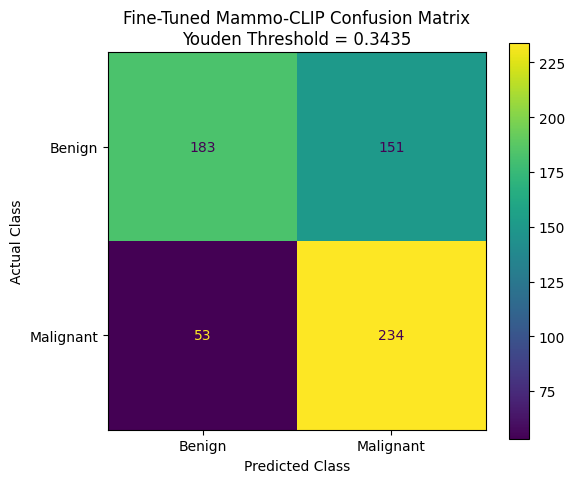

Saved: /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/finetune_validation_confusion_matrix.png


In [81]:
# from sklearn.metrics import (
#     ConfusionMatrixDisplay,
#     classification_report,
# )
# import matplotlib.pyplot as plt


finetune_optimal_predictions = (
    finetune_probabilities
    >= finetune_optimal_threshold
).astype(np.int64)

print(
    classification_report(
        finetune_labels,
        finetune_optimal_predictions,
        target_names=[
            "Benign",
            "Malignant",
        ],
        digits=4,
        zero_division=0,
    )
)

FINETUNE_CONFUSION_MATRIX_PATH = (
    OUTPUT_DIR
    / "finetune_validation_confusion_matrix.png"
)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    finetune_labels,
    finetune_optimal_predictions,
    display_labels=[
        "Benign",
        "Malignant",
    ],
    values_format="d",
    ax=ax,
)

ax.set_title(
    "Fine-Tuned Mammo-CLIP Confusion Matrix\n"
    f"Youden Threshold = "
    f"{finetune_optimal_threshold:.4f}"
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    FINETUNE_CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FINETUNE_CONFUSION_MATRIX_PATH,
)

## **Save the fine-tuning evaluation results**

In [82]:
# import json


finetune_val_prediction_df[
    "prediction_threshold_05"
] = (
    finetune_probabilities >= 0.5
).astype(np.int64)

finetune_val_prediction_df[
    "prediction_youden"
] = (
    finetune_probabilities
    >= finetune_optimal_threshold
).astype(np.int64)

FINETUNE_PREDICTION_PATH = (
    OUTPUT_DIR
    / "finetune_validation_predictions.csv"
)

FINETUNE_THRESHOLD_COMPARISON_PATH = (
    OUTPUT_DIR
    / "finetune_threshold_comparison.csv"
)

FINETUNE_EVALUATION_SUMMARY_PATH = (
    OUTPUT_DIR
    / "finetune_evaluation_summary.json"
)

finetune_val_prediction_df.to_csv(
    FINETUNE_PREDICTION_PATH,
    index=False,
)

finetune_threshold_comparison_df.to_csv(
    FINETUNE_THRESHOLD_COMPARISON_PATH,
    index=False,
)

finetune_evaluation_summary = {
    "model": "Mammo-CLIP B2",
    "training_stage": "partial_finetune",
    "best_epoch": int(
        best_finetune_checkpoint["epoch"]
    ),
    "validation_samples": int(
        len(finetune_labels)
    ),
    "positive_prevalence": float(
        finetune_labels.mean()
    ),
    "validation_roc_auc": float(
        finetune_roc_auc
    ),
    "validation_pr_auc_trapezoidal": float(
        finetune_pr_auc
    ),
    "validation_average_precision": float(
        finetune_average_precision
    ),
    "default_threshold": 0.5,
    "youden_threshold": float(
        finetune_optimal_threshold
    ),
    "youden_j": float(
        ft_youden_j[
            ft_best_threshold_index
        ]
    ),
    "metrics_threshold_05": (
        finetune_metrics_threshold_05
    ),
    "metrics_youden_threshold": (
        finetune_metrics_optimal
    ),
    "linear_probe_roc_auc": float(
        best_linear_checkpoint[
            "best_val_auc"
        ]
    ),
    "roc_auc_improvement": float(
        finetune_roc_auc
        - best_linear_checkpoint[
            "best_val_auc"
        ]
    ),
}

with open(
    FINETUNE_EVALUATION_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        finetune_evaluation_summary,
        file,
        indent=2,
    )

print(
    "Predictions:",
    FINETUNE_PREDICTION_PATH,
)
print(
    "Comparison :",
    FINETUNE_THRESHOLD_COMPARISON_PATH,
)
print(
    "Summary    :",
    FINETUNE_EVALUATION_SUMMARY_PATH,
)

Predictions: /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/finetune_validation_predictions.csv
Comparison : /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/finetune_threshold_comparison.csv
Summary    : /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/finetune_evaluation_summary.json


In [83]:
FINAL_TEACHER_INFO_PATH = (
    OUTPUT_DIR / "final_teacher_info.json"
)

final_teacher_info = {
    "teacher_model": "Mammo-CLIP B2",
    "selected_stage": "partial_finetune",
    "selected_epoch": 6,
    "checkpoint_path": str(
        BEST_FINETUNE_PATH
    ),
    "validation_roc_auc": float(
        finetune_roc_auc
    ),
    "validation_pr_auc": float(
        finetune_pr_auc
    ),
    "validation_average_precision": float(
        finetune_average_precision
    ),
    "validation_youden_threshold": float(
        finetune_optimal_threshold
    ),
    "feature_dimension": 1408,
    "projection_dimension": 512,
    "trainable_blocks": [21, 22],
}

with open(
    FINAL_TEACHER_INFO_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_teacher_info,
        file,
        indent=2,
    )

print("Final teacher information saved:")
print(FINAL_TEACHER_INFO_PATH)

Final teacher information saved:
/content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/final_teacher_info.json
